# Imports

In [1]:
from train.test import GANTester

import torch, os
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from skimage.transform import resize, rescale
from scipy.ndimage import rotate
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Loading Data

In [2]:
from config.options import Options
opt = Options().parse()

from data.data import CombinedDatasetV3

dataset = CombinedDatasetV3(opt.folder_path) 

# Access the datasets using indexing
train_dataset = dataset['train']  # Get train dataset
test_dataset = dataset['test']    # Get test dataset

# Pass the dataset to DataLoader
train_loader = DataLoader(train_dataset, batch_size=opt.batchsize, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=opt.batchsize, shuffle=False)

2025-07-28 02:34:28,730 - INFO - Loaded 2580 samples from train folder.
2025-07-28 02:34:28,731 - INFO - Train Dataset: 2409 benign, 171 malignant nodules.
2025-07-28 02:34:28,733 - INFO - Loaded 245 samples from test folder.
2025-07-28 02:34:28,733 - INFO - Test Dataset: 74 benign, 171 malignant nodules.


# Loading desired network weights

In [3]:
import os

# Absolute path to your weights folder
base_weights_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights"

# Define the weight values
w_values = [0.1, 1.0, 10, 20, 30, 50]

# Store metrics separately
mse_results = {}
sum_results = {}
latent_results = {}

for w in w_values:
    print(f"\n=== Testing Model with w = {w} ===")

    model_filename = f"model_wmmd_{w}.pth"
    load_path = os.path.join(base_weights_path, model_filename)

    if not os.path.exists(load_path):
        print(f"❌ File not found: {load_path}")
        continue

    # Load model
    LunGAN = GANLung(opt)
    LunGAN.seed(41)
    LunGAN.load_model(load_path)

    # Run test
    tester = GANTester(LunGAN, train_loader, test_loader, LunGAN.device)
    tester.alpha = 0.8
    best_thresholds = tester.get_threshold_precision_recall(train_loader)
    metrics, y_true, scores = tester.test()
    classification_results, __ = tester.calculate_classification_metrics(
        best_thresholds, metrics, y_true=y_true, scores=scores
    )

    # Store results
    if "mse" in classification_results:
        mse_results[w] = classification_results["mse"]
    if "sum" in classification_results:
        sum_results[w] = classification_results["sum"]
    if "latent" in classification_results:
        latent_results[w] = classification_results["latent"]

# Function to print a table for a given metric type
def print_metric_table(results_dict, label="mse"):
    print(f"\n### Results for: {label.upper()} ###")
    print("w\tspecificity\trecall\tprecision\tf1\tauc")
    for w in sorted(results_dict.keys()):
        m = results_dict[w]
        print(f"{w}\t{m['specificity']:.4f}\t{m['recall']:.4f}\t{m['precision']:.4f}\t{m['f1']:.4f}\t{m['auc']:.4f}")

# Print all three tables
print_metric_table(mse_results, "mse")
print_metric_table(sum_results, "sum")
print_metric_table(latent_results, "latent")



=== Testing Model with w = 0.1 ===

=== Testing Model with w = 1.0 ===

=== Testing Model with w = 10 ===

=== Testing Model with w = 20 ===

=== Testing Model with w = 30 ===

=== Testing Model with w = 50 ===

### Results for: MSE ###
w	specificity	recall	precision	f1	auc
0.1	0.8108	0.9064	0.9172	0.9118	0.9374
1.0	0.7973	0.8655	0.9080	0.8862	0.9288
10	0.8378	0.8830	0.9264	0.9042	0.9399
20	0.7838	0.9064	0.9064	0.9064	0.9343
30	0.7973	0.9181	0.9128	0.9155	0.9305
50	0.8649	0.8889	0.9383	0.9129	0.9370

### Results for: SUM ###
w	specificity	recall	precision	f1	auc
0.1	0.7973	0.9064	0.9118	0.9091	0.9372
1.0	0.7973	0.8655	0.9080	0.8862	0.9287
10	0.8378	0.8830	0.9264	0.9042	0.9399
20	0.7838	0.9064	0.9064	0.9064	0.9343
30	0.7973	0.9181	0.9128	0.9155	0.9305
50	0.8649	0.8889	0.9383	0.9129	0.9370

### Results for: LATENT ###
w	specificity	recall	precision	f1	auc
0.1	0.7703	0.8596	0.8963	0.8776	0.9109
1.0	0.8649	0.7895	0.9310	0.8544	0.8943
10	0.9189	0.5439	0.9394	0.6889	0.8788
20	0.9189	0.5731	

In [3]:
import importlib
import models.latstats.network
import models.base.network
import models.morph.network
import models.sobel.network
import config.options
importlib.reload(models.latstats.network)
importlib.reload(models.base.network)
importlib.reload(models.morph.network)
importlib.reload(models.sobel.network)
importlib.reload(config.options)

from config.options import Options
opt = Options().parse()

from models.morph.network import GANLung  

load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"

LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

from scripts.plotting import plot_classification_metrics, plot_confusion_matrix



def format_metrics(metrics_dict):
    # Create a list to hold the rows of the table
    rows = []
    
    # Collect the data for each model and metric, excluding 'latent'
    for model, metrics in metrics_dict.items():
        if model == "latent":
            continue  # Skip the 'latent' model
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    
    # Create a DataFrame from the collected rows
    df = pd.DataFrame(rows)
    
    return df

            
tester = GANTester(LunGAN, train_loader, test_loader, LunGAN.device)
tester.alpha = 0.8
best_thresholds = tester.get_threshold_precision_recall(train_loader)
metrics, y_true, scores = tester.test()
classification_results, __ = tester.calculate_classification_metrics(best_thresholds, metrics, y_true=y_true, scores=scores)
# plot_classification_metrics(classification_results)
# plot_confusion_matrix(y_true, y_pred, title='Test Set Confusion Matrix')
format_metrics(classification_results)

,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,69,5,28,143,0.932432,0.836257,0.966216,0.896552,0.952110
1,sum,64,10,35,136,0.864865,0.795322,0.931507,0.858044,0.925162


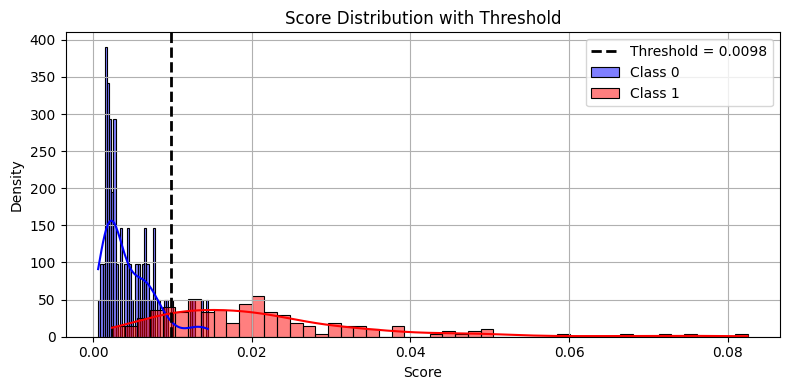

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution(y_true, scores, threshold, title="Score Distribution with Threshold"):
    plt.figure(figsize=(8, 4))
    
    # Convert to NumPy arrays
    scores = np.array(scores["mse"])
    y_true = np.array(y_true)
    
    # Separate scores for the two classes
    class_0_scores = scores[y_true == 0]
    class_1_scores = scores[y_true == 1]

    # Plot distributions
    sns.histplot(class_0_scores, bins=50, color='blue', label='Class 0', kde=True, stat='density')
    sns.histplot(class_1_scores, bins=50, color='red', label='Class 1', kde=True, stat='density')

    # Plot threshold line
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')

    plt.title(title)
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_score_distribution(y_true, scores, best_thresholds["mse"])


# LNDB

In [12]:
df = pd.read_csv("/data/Datasets/Lungs/LNDb/CSVs/nodules_consensous.csv")
df_filtered = df[(df["RadID"] == 3) & (df["malignancy"] != 2)]
df_filtered.to_csv("nodules_consensous_filtered3R.csv", index=False)

In [13]:
df = pd.read_csv("/data/Datasets/Lungs/LNDb/CSVs/nodules_consensous.csv")
df_filtered = df[(df["RadID"] == 3) & (df["malignancy"] != 2)]
df_filtered = pd.concat([df_filtered, df[(df["RadID"] == 2) & (df["malignancy"] != 2)]])
df_filtered.to_csv("nodules_consensous_filtered2R.csv", index=False)


## Carga de Datos

In [56]:
import os
import numpy as np
import pandas as pd
from skimage.transform import resize
import torch
from torch.utils.data import Dataset, DataLoader
from config.options import Options
opt = Options().parse()


# Define a dataset class for the test data
class TestDataset(Dataset):
    def __init__(self, data_list, labels):
        self.data_list = data_list
        self.labels = labels

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        data = self.data_list[idx]
        data = np.expand_dims(data, axis=0)  
        data = np.ascontiguousarray(data)    # Ensure the array is contiguous in memory
        label = self.labels[idx]
        return torch.from_numpy(data).float(), torch.tensor(label).float()


# Función para filtrar solo los nódulos benignos (y == 0)
def create_benign_dataset(X_data, y_data):
    benign_indices = np.where(y_data == 0)[0]  # Obtiene los índices de las muestras benignas
    X_benign = X_data[benign_indices]
    y_benign = y_data[benign_indices]
    return X_benign, y_benign

# Load the CSV file
df = pd.read_csv("nodules_consensous_filtered3R.csv")
FOLDER3R = df['nodule']
LNDbPATH = '/data/Datasets/Lungs/LNDb/LNDb_cropped_2D/'

# Load the nodule data
unresizedLNDb = [np.load(os.path.join(LNDbPATH, npy + ".npy")) for npy in FOLDER3R]
# Resize the images
max_shape = (32, 32)
LNDb = [resize(image, max_shape, mode='wrap', anti_aliasing=False) for image in unresizedLNDb]
LNDb = [(sample - np.min(sample)) / (np.max(sample) - np.min(sample)) for sample in LNDb]

# Separate the nodules into benign and malignant based on the malignancy value
malignantLNDb = []
benignLNDb = []
ValuesLNDb = df['malignancy'].tolist()
for idx in range(len(ValuesLNDb)):
    if ValuesLNDb[idx] < 2:
        benignLNDb.append(LNDb[idx])
    elif ValuesLNDb[idx] > 2:
        malignantLNDb.append(LNDb[idx])

# Combine benign and malignant nodules
allLNDb = benignLNDb + malignantLNDb
labelsLNDb = [0] * len(benignLNDb) + [1] * len(malignantLNDb)

X_train, X_test, y_train, y_test = train_test_split(allLNDb, labelsLNDb, test_size=0.8, random_state=42)

# Create the test dataset
test_dataset_new = TestDataset(X_test, y_test)
test_loader_new_arch = DataLoader(test_dataset_new, batch_size=opt.batchsize, shuffle=False)

train_dataset_new = TestDataset(X_train, y_train)
train_loader_new_arch = DataLoader(train_dataset_new, batch_size=opt.batchsize, shuffle=False)

In [57]:
from collections import Counter

# Count samples in training set
train_counts = Counter(y_train)
print("📦 Training Set")
print(f"   ✅ Benign (0): {train_counts[0]}")
print(f"   ⚠️ Malignant (1): {train_counts[1]}")
print(f"   🧮 Total: {len(y_train)}")

# Count samples in test set
test_counts = Counter(y_test)
print("\n🧪 Test Set")
print(f"   ✅ Benign (0): {test_counts[0]}")
print(f"   ⚠️ Malignant (1): {test_counts[1]}")
print(f"   🧮 Total: {len(y_test)}")


📦 Training Set
   ✅ Benign (0): 12
   ⚠️ Malignant (1): 6
   🧮 Total: 18

🧪 Test Set
   ✅ Benign (0): 50
   ⚠️ Malignant (1): 22
   🧮 Total: 72


## Inferencia Zero-Shot

In [4]:

load_path = "/data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"

import importlib
import models.latstats.network
import models.base.network
import models.morph.network
import models.sobel.network
import config.options
importlib.reload(models.latstats.network)
importlib.reload(models.base.network)
importlib.reload(models.morph.network)
importlib.reload(models.sobel.network)
importlib.reload(config.options)

from config.options import Options
opt = Options().parse()

from models.morph.network import GANLung  

LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

def format_metrics(metrics_dict):
    # Create a list to hold the rows of the table
    rows = []
    
    # Collect the data for each model and metric, excluding 'latent'
    for model, metrics in metrics_dict.items():
        if model == "latent":
            continue  # Skip the 'latent' model
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    
    # Create a DataFrame from the collected rows
    df = pd.DataFrame(rows)
    
    return df

            
tester = GANTester(LunGAN, train_loader_new_arch, test_loader_new_arch, LunGAN.device)
tester.alpha = 0.0
best_thresholds = tester.get_threshold_precision_recall(train_loader_new_arch)
metrics, y_true, scores = tester.test()
classification_results, __ = tester.calculate_classification_metrics(best_thresholds, metrics, y_true=y_true, scores=scores)
# plot_classification_metrics(classification_results)
# plot_confusion_matrix(y_true, y_pred, title='Test Set Confusion Matrix')
format_metrics(classification_results)

Loading model from /data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth


,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,1,136,1,146,0.007299,0.993197,0.517730,0.680653,0.528725
1,sum,1,136,0,147,0.007299,1.000000,0.519435,0.683721,0.513779


## Fine - Tuning

### Few-Shot Base

In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from collections import defaultdict

def fine_tune_ganlung(opt, X_train, y_train, load_path, f_epoch=30):
    """
    Fine-tunes a pretrained GANLung model using only benign samples.
    
    Args:
        opt: Configuration object (should include opt.batchsize and opt.seed).
        X_train (list or np.ndarray): Training images.
        y_train (list or np.ndarray): Corresponding binary labels.
        load_path (str): Path to load the pretrained model.
        f_epoch (int): Number of fine-tuning epochs.
    
    Returns:
        lungan: Fine-tuned GANLung model.
    """

    # Convert to NumPy arrays if necessary
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # Filter only benign samples (label = 0)
    X_benign, y_benign = create_benign_dataset(X_train, y_train)    

    # Create dataset and dataloader
    train_dataset_benign = TestDataset(X_benign, y_benign)
    train_loader_benign = DataLoader(train_dataset_benign, batch_size=opt.batchsize, shuffle=True)

    # Load pretrained model
    lungan = GANLung(opt)
    lungan.load_model(load_path)
    lungan.seed(opt.seed)

    # Dictionary to track losses
    all_losses = defaultdict(list)

    # Fine-tuning loop
    for epoch in range(f_epoch):
        for i, (data, _) in enumerate(train_loader_benign):
            input = data.to(lungan.device).float()

            # Optimize parameters and capture all losses
            err_g, err_d, err_g_con, err_g_adv, err_g_enc, err_mmd = lungan.optimize_params(input)

            # Print and store losses
            if i % 100 == 0:
                print(f"[Epoch {epoch+1}/{f_epoch}] [Step {i}/{len(train_loader_benign)}] "
                      f"G: {err_g.item():.5f} | D: {err_d.item():.5f} | "
                      f"Con: {err_g_con.item():.5f} | Adv: {err_g_adv.item():.5f} | "
                      f"Enc: {err_g_enc.item():.5f} | MMD: {err_mmd.item():.5f}")

            all_losses['err_g'].append(err_g.item())
            all_losses['err_d'].append(err_d.item())
            all_losses['err_g_con'].append(err_g_con.item())
            all_losses['err_g_adv'].append(err_g_adv.item())
            all_losses['err_g_enc'].append(err_g_enc.item())
            all_losses['err_mmd'].append(err_mmd.item())

    return lungan, all_losses

# Calling
LunGAN, losses = fine_tune_ganlung(opt, X_train, y_train, load_path=load_path, f_epoch=500)

Loading model from /data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth
[Epoch 1/500] [Step 0/2] G: 1.62861 | D: 2.99806 | Con: 0.00618 | Adv: 0.88468 | Enc: 0.00398 | MMD: 0.04307
[Epoch 2/500] [Step 0/2] G: 1.27634 | D: 1.48976 | Con: 0.00637 | Adv: 0.78462 | Enc: 0.00345 | MMD: 0.01696
[Epoch 3/500] [Step 0/2] G: 1.17119 | D: 0.21690 | Con: 0.00614 | Adv: 0.76453 | Enc: 0.00254 | MMD: 0.00973
[Epoch 4/500] [Step 0/2] G: 1.10082 | D: 0.12304 | Con: 0.00558 | Adv: 0.73326 | Enc: 0.00275 | MMD: 0.00859
[Epoch 5/500] [Step 0/2] G: 1.07679 | D: 0.05001 | Con: 0.00450 | Adv: 0.69843 | Enc: 0.00277 | MMD: 0.01506
[Epoch 6/500] [Step 0/2] G: 1.01056 | D: 0.03619 | Con: 0.00463 | Adv: 0.69930 | Enc: 0.00255 | MMD: 0.00772
[Epoch 7/500] [Step 0/2] G: 0.95311 | D: 0.01280 | Con: 0.00407 | Adv: 0.67523 | Enc: 0.00228 | MMD: 0.00719
[Epoch 8/500] [Step 0/2] G: 0.89306 | D: 0.02872 | Con: 0.00444 | Adv: 0.60690 | Enc: 0.00256 | MMD: 0.00616
[Epoch 9/500] [Step 0/2] 

### LR reduced

In [23]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from collections import defaultdict

def fine_tune_ganlung(opt, X_train, y_train, load_path, f_epoch=30, lr_scale=0.1):
    """
    Fine-tunes a pretrained GANLung model using only benign samples.

    Args:
        opt: Configuration object (should include opt.batchsize and opt.seed).
        X_train (list or np.ndarray): Training images.
        y_train (list or np.ndarray): Corresponding binary labels.
        load_path (str): Path to load the pretrained model.
        f_epoch (int): Number of fine-tuning epochs.
        lr_scale (float): Scaling factor to reduce the learning rate (e.g., 0.1 for 10x lower).

    Returns:
        lungan: Fine-tuned GANLung model.
        all_losses: Dictionary with loss tracking.
    """

    # Convert to NumPy arrays if necessary
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # Filter only benign samples (label = 0)
    X_benign, y_benign = create_benign_dataset(X_train, y_train)

    # Create dataset and dataloader
    train_dataset_benign = TestDataset(X_benign, y_benign)
    train_loader_benign = DataLoader(train_dataset_benign, batch_size=opt.batchsize, shuffle=True)

    # Load pretrained model
    lungan = GANLung(opt)
    lungan.load_model(load_path)
    lungan.seed(opt.seed)

    # ↓↓↓ Reduce learning rate for both generator and discriminator
    for param_group in lungan.optimizer_G.param_groups:
        param_group['lr'] *= lr_scale
    for param_group in lungan.optimizer_D.param_groups:
        param_group['lr'] *= lr_scale

    print(f"Learning rate scaled by {lr_scale}. New LR (G): {lungan.optimizer_G.param_groups[0]['lr']:.6f}, "
        f"(D): {lungan.optimizer_D.param_groups[0]['lr']:.6f}")

    # Dictionary to track losses
    all_losses = defaultdict(list)

    # Fine-tuning loop
    for epoch in range(f_epoch):
        for i, (data, _) in enumerate(train_loader_benign):
            input = data.to(lungan.device).float()

            # Optimize parameters and capture all losses
            err_g, err_d, err_g_con, err_g_adv, err_g_enc, err_mmd = lungan.optimize_params(input)

            # Print and store losses
            if i % 100 == 0:
                print(f"[Epoch {epoch+1}/{f_epoch}] [Step {i}/{len(train_loader_benign)}] "
                      f"G: {err_g.item():.5f} | D: {err_d.item():.5f} | "
                      f"Con: {err_g_con.item():.5f} | Adv: {err_g_adv.item():.5f} | "
                      f"Enc: {err_g_enc.item():.5f} | MMD: {err_mmd.item():.5f}")

            all_losses['err_g'].append(err_g.item())
            all_losses['err_d'].append(err_d.item())
            all_losses['err_g_con'].append(err_g_con.item())
            all_losses['err_g_adv'].append(err_g_adv.item())
            all_losses['err_g_enc'].append(err_g_enc.item())
            all_losses['err_mmd'].append(err_mmd.item())

    return lungan, all_losses

LunGAN, losses = fine_tune_ganlung(opt, X_train, y_train, load_path=load_path, f_epoch=30, lr_scale=0.01)

Loading model from /data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth
Learning rate scaled by 0.01. New LR (G): 0.000002, (D): 0.000002
[Epoch 1/30] [Step 0/2] G: 2.92075 | D: 2.99806 | Con: 0.00618 | Adv: 0.88468 | Enc: 0.00398 | MMD: 0.04307
[Epoch 2/30] [Step 0/2] G: 2.79188 | D: 2.66750 | Con: 0.00718 | Adv: 0.80734 | Enc: 0.00390 | MMD: 0.04054
[Epoch 3/30] [Step 0/2] G: 2.36449 | D: 3.75382 | Con: 0.00754 | Adv: 0.84252 | Enc: 0.00334 | MMD: 0.02854
[Epoch 4/30] [Step 0/2] G: 2.34840 | D: 2.97752 | Con: 0.00781 | Adv: 0.85054 | Enc: 0.00366 | MMD: 0.02760
[Epoch 5/30] [Step 0/2] G: 2.25727 | D: 3.37779 | Con: 0.00652 | Adv: 0.84247 | Enc: 0.00359 | MMD: 0.02713
[Epoch 6/30] [Step 0/2] G: 2.08229 | D: 2.66605 | Con: 0.00601 | Adv: 0.81736 | Enc: 0.00341 | MMD: 0.02403
[Epoch 7/30] [Step 0/2] G: 1.97141 | D: 2.62324 | Con: 0.00620 | Adv: 0.85109 | Enc: 0.00305 | MMD: 0.02018
[Epoch 8/30] [Step 0/2] G: 1.98898 | D: 2.36457 | Con: 0.00712 | Adv: 0.816

### Frozen Layers

In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from collections import defaultdict

def freeze_module(module):
    """Utility to freeze all parameters in a given module."""
    for param in module.parameters():
        param.requires_grad = False

def fine_tune_ganlung(opt, X_train, y_train, load_path, f_epoch=30, lr_scale=0.1):
    """
    Fine-tunes a pretrained GANLung model using only benign samples.

    Args:
        opt: Configuration object (should include opt.batchsize, opt.lr, and opt.seed).
        X_train (list or np.ndarray): Training images.
        y_train (list or np.ndarray): Corresponding binary labels.
        load_path (str): Path to load the pretrained model.
        f_epoch (int): Number of fine-tuning epochs.
        lr_scale (float): Scaling factor to reduce the learning rate (e.g., 0.1 for 10x lower).

    Returns:
        lungan: Fine-tuned GANLung model.
        all_losses: Dictionary with loss tracking.
    """

    # Convert to NumPy arrays if necessary
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # Filter only benign samples (label = 0)
    X_benign, y_benign = create_benign_dataset(X_train, y_train)

    # Create dataset and dataloader
    train_dataset_benign = TestDataset(X_benign, y_benign)
    train_loader_benign = DataLoader(train_dataset_benign, batch_size=opt.batchsize, shuffle=True)

    # Load pretrained model
    lungan = GANLung(opt)
    lungan.load_model(load_path)
    lungan.seed(opt.seed)

    # ===================== 🔒 FREEZING ===================== #
    # netG = lungan.discriminator

    # # Freeze encoder1 and encoder2 (GANomaly style)
    # if hasattr(netG, 'decoder'):
    #     freeze_module(netG.decoder)
    #     print("[Freeze] decoder frozen.")
    # # if hasattr(netG, 'encoder2'):
    # #     freeze_module(netG.encoder2)
    # #     print("[Freeze] encoder2 frozen.")

    # # Optional: print frozen modules
    # for name, param in netG.named_parameters():
    #     if not param.requires_grad:
    #         print(f"[Frozen] {name}")

    # ======================================================= #

    # ↓↓↓ Rebuild optimizer_G using only trainable parameters
    # lungan.optimizer_G = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, netG.parameters()),
    #     lr=0.00002,
    #     betas=(0.5, 0.999)
    # )

    lungan.optimizer_G = torch.optim.Adam(
        filter(lambda p: p.requires_grad, lungan.generator.parameters()),
        lr=0.00002,
        betas=(0.5, 0.999)
    )
    # lungan.optimizer_G = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, lungan.discriminator.parameters()),
    #     lr=0.00002,
    #     betas=(0.5, 0.999)
    # )

    # ↓↓↓ Reduce learning rate for discriminator
    for param_group in lungan.optimizer_D.param_groups:
        param_group['lr'] *= lr_scale

    print(f"Learning rate scaled by {lr_scale}. New LR (G): {lungan.optimizer_G.param_groups[0]['lr']:.6f}, "
          f"(D): {lungan.optimizer_D.param_groups[0]['lr']:.6f}")

    # Dictionary to track losses
    all_losses = defaultdict(list)

    # Fine-tuning loop
    for epoch in range(f_epoch):
        for i, (data, _) in enumerate(train_loader_benign):
            input = data.to(lungan.device).float()

            # Optimize parameters and capture all losses
            err_g, err_d, err_g_con, err_g_adv, err_g_enc, err_mmd = lungan.optimize_params(input)

            # Print and store losses
            if i % 100 == 0:
                print(f"[Epoch {epoch+1}/{f_epoch}] [Step {i}/{len(train_loader_benign)}] "
                      f"G: {err_g.item():.5f} | D: {err_d.item():.5f} | "
                      f"Con: {err_g_con.item():.5f} | Adv: {err_g_adv.item():.5f} | "
                      f"Enc: {err_g_enc.item():.5f} | MMD: {err_mmd.item():.5f}")

            all_losses['err_g'].append(err_g.item())
            all_losses['err_d'].append(err_d.item())
            all_losses['err_g_con'].append(err_g_con.item())
            all_losses['err_g_adv'].append(err_g_adv.item())
            all_losses['err_g_enc'].append(err_g_enc.item())
            all_losses['err_mmd'].append(err_mmd.item())

    return lungan, all_losses


LunGAN, losses = fine_tune_ganlung(opt, X_train, y_train, load_path=load_path, f_epoch=500, lr_scale=0.01)

Loading model from /data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth
Learning rate scaled by 0.01. New LR (G): 0.000020, (D): 0.000002
[Epoch 1/500] [Step 0/2] G: 1.62861 | D: 2.99806 | Con: 0.00618 | Adv: 0.88468 | Enc: 0.00398 | MMD: 0.04307
[Epoch 2/500] [Step 0/2] G: 1.55228 | D: 2.59134 | Con: 0.00711 | Adv: 0.80163 | Enc: 0.00388 | MMD: 0.03913
[Epoch 3/500] [Step 0/2] G: 1.47669 | D: 3.55881 | Con: 0.00738 | Adv: 0.83527 | Enc: 0.00330 | MMD: 0.02689
[Epoch 4/500] [Step 0/2] G: 1.48340 | D: 2.67914 | Con: 0.00760 | Adv: 0.84045 | Enc: 0.00363 | MMD: 0.02594
[Epoch 5/500] [Step 0/2] G: 1.39534 | D: 2.95808 | Con: 0.00630 | Adv: 0.82346 | Enc: 0.00356 | MMD: 0.02532
[Epoch 6/500] [Step 0/2] G: 1.31855 | D: 2.20574 | Con: 0.00580 | Adv: 0.80322 | Enc: 0.00338 | MMD: 0.02219
[Epoch 7/500] [Step 0/2] G: 1.31480 | D: 2.05648 | Con: 0.00596 | Adv: 0.83321 | Enc: 0.00302 | MMD: 0.01807
[Epoch 8/500] [Step 0/2] G: 1.30788 | D: 1.84291 | Con: 0.00672 | Ad

## Inferencia

Correr despues de cargar el modelo o después de realizar Fine-Tuning

In [7]:
# Create tester with the updated model
tester = GANTester(LunGAN, train_loader_new_arch, test_loader_new_arch, LunGAN.device)

# Set alpha for thresholding
tester.alpha = 0

# Get optimal threshold from benign training data
best_thresholds = tester.get_threshold_precision_recall(train_loader_new_arch)

# Run inference
metrics, y_true, scores = tester.test()

# Compute classification metrics using the threshold
classification_results, __ = tester.calculate_classification_metrics(
    best_thresholds, metrics, y_true=y_true, scores=scores
)

def format_metrics(metrics_dict):
    rows = []
    for model, metrics in metrics_dict.items():
        # if model == "latent":
        #     continue
        row = {"Model": model}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

results_df = format_metrics(classification_results)
results_df


,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,41,96,36,111,0.299270,0.755102,0.536232,0.627119,0.519440
1,latent,1,136,0,147,0.007299,1.000000,0.519435,0.683721,0.514375
2,sum,1,136,0,147,0.007299,1.000000,0.519435,0.683721,0.514375


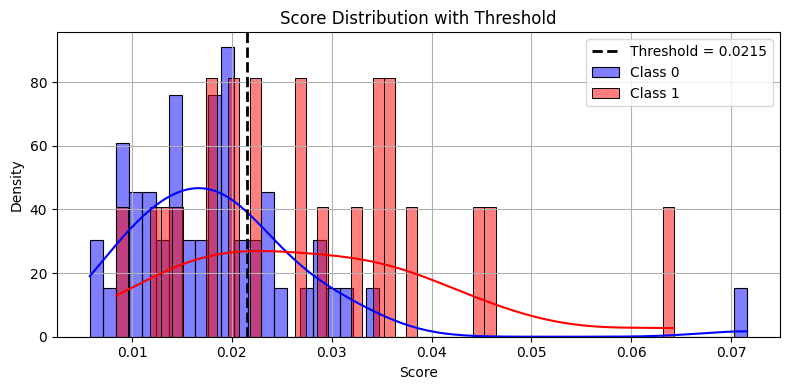

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution(y_true, scores, threshold, title="Score Distribution with Threshold"):
    plt.figure(figsize=(8, 4))
    
    # Convert to NumPy arrays
    scores = np.array(scores["mse"])
    y_true = np.array(y_true)
    
    # Separate scores for the two classes
    class_0_scores = scores[y_true == 0]
    class_1_scores = scores[y_true == 1]

    # Plot distributions
    sns.histplot(class_0_scores, bins=50, color='blue', label='Class 0', kde=True, stat='density')
    sns.histplot(class_1_scores, bins=50, color='red', label='Class 1', kde=True, stat='density')

    # Plot threshold line
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')

    plt.title(title)
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_score_distribution(y_true, scores, best_thresholds["mse"])


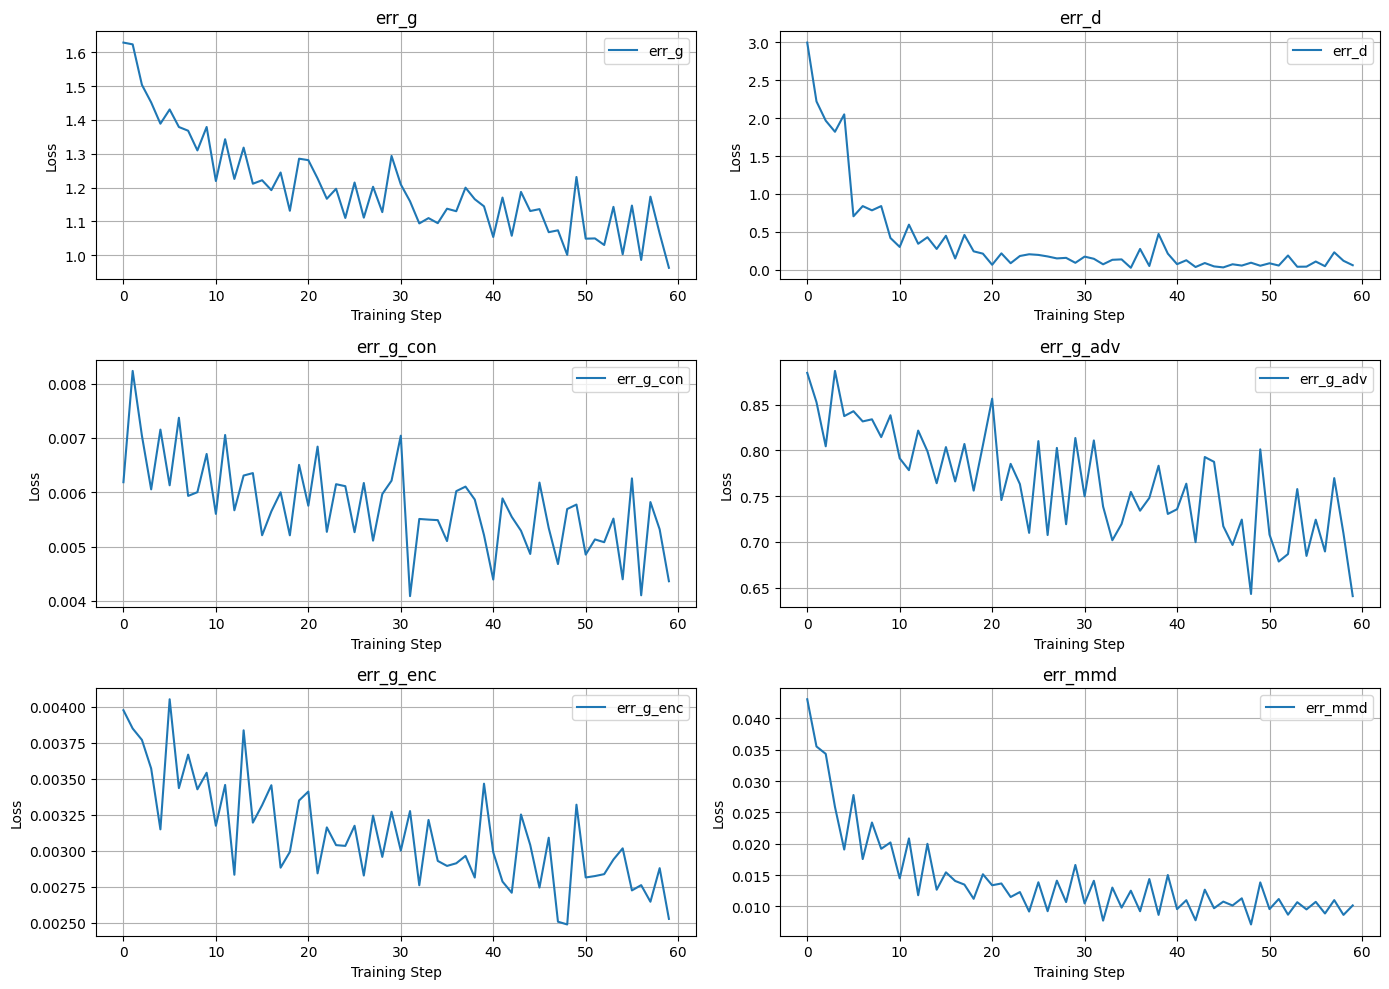

In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

# Plot all in a single figure with 6 subplots
def plot_all_losses_subplots(all_losses):
    loss_names = list(all_losses.keys())
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, loss_name in enumerate(loss_names):
        axes[idx].plot(all_losses[loss_name], label=loss_name)
        axes[idx].set_title(f'{loss_name}')
        axes[idx].set_xlabel('Training Step')
        axes[idx].set_ylabel('Loss')
        axes[idx].grid(True)
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

# Call function with simulated losses
plot_all_losses_subplots(losses)


## Latent Spaces

In [ ]:
tester.plot_tsne()
tester.plot_pca()

In [ ]:
index_to_plot = 45  # Change this to plot a different index
plot_images(results['real_images'], results['generated_images'], index_to_plot)

In [ ]:
from data import CustomDatasetV4
from options import Options
opt = Options().parse()

def count_data_per_fold_and_type(main_folder):
    fold_stats = {}
    for fold in range(10):
        fold_stats[fold] = {'train_benign': 0, 'train_malignant': 0, 'test_benign': 0, 'test_malignant': 0}
        
        # Initialize train and test datasets
        train_dataset = CustomDatasetV4(main_folder, num_fold=fold, dataset_type='train')
        test_dataset = CustomDatasetV4(main_folder, num_fold=fold, dataset_type='test')

        # Count benign samples in the training dataset
        fold_stats[fold]['train_benign'] = len(train_dataset)
        # Training set only contains benign samples, so 'train_malignant' is always 0
        fold_stats[fold]['train_malignant'] = 0

        # Count benign and malignant samples in the test dataset
        for _, label in test_dataset:
            if label.item() == 0:
                fold_stats[fold]['test_benign'] += 1
            elif label.item() == 1:
                fold_stats[fold]['test_malignant'] += 1

    return fold_stats

# Count the data per fold
fold_data_counts = count_data_per_fold_and_type(opt.folder_path)

# Print the results
for fold, counts in fold_data_counts.items():
    print(f"Fold {fold}:")
    print(f"  Train benign (0): {counts['train_benign']}")
    print(f"  Train malignant (1): {counts['train_malignant']}")
    print(f"  Test benign (0): {counts['test_benign']}")
    print(f"  Test malignant (1): {counts['test_malignant']}")

In [61]:
import matplotlib.pyplot as plt
# Test
s = np.load("/home/arumota_pupils/Josue/EMBC_Extention/Data/test/benign/nodule_539.npy")
print(s.shape)
plt.imshow(s, cmap='gray')

FileNotFoundError: [Errno 2] No such file or directory: '/home/arumota_pupils/Josue/EMBC_Extention/Data/test/benign/nodule_539.npy'

# Histopathological Inference

## Dataloader

In [5]:
import pandas as pd
import numpy as np
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize

class NoduleDataset(Dataset):
    def __init__(self, hist, npy_dir):
        """
        Args:
            hist (pd.DataFrame): DataFrame containing metadata (must include 'nodule_id' and 'malignancy').
            npy_dir (str): Directory containing .npy files for nodules.
        """
        # Filter the DataFrame based on conditions
        hist = hist.loc[
            (hist['malignancy'] > 0) &
            (hist['method'] != 0) &
            (hist['malignancy'] != 3.0)
        ]
        hist = hist[~hist['nodule_id'].str.startswith("LIDC-IDRI-0332")]

        # Map malignancy: 1 → 0, everything else → 1
        hist.loc[:, 'malignancy'] = hist['malignancy'].map(lambda x: 0 if x == 1 else 1)

        self.npy_dir = npy_dir
        self.nodule_ids = []
        self.labels = []
        self.missing_files = []

        # Check for missing files and filter the dataset
        for nodule_id, label in zip(hist['nodule_id'], hist['malignancy']):
            file_pattern = os.path.join(self.npy_dir, f"{nodule_id}.npy")  # Updated pattern

            # Match files based on the new naming convention
            matching_files = glob.glob(file_pattern)

            if len(matching_files) == 0:
                # Record missing files but skip them
                self.missing_files.append(nodule_id)
                continue
            elif len(matching_files) > 1:
                raise ValueError(f"Multiple files found for nodule ID: {nodule_id} - {matching_files}")
            
            # Add the valid file and label
            self.nodule_ids.append(matching_files[0])  # Store the full file path
            self.labels.append(label)

        # Print missing files if any
        if self.missing_files:
            print(f"Warning: {len(self.missing_files)} files not found. Missing nodule IDs:")
            print(", ".join(self.missing_files))

        # Check if no valid samples are left
        if len(self.nodule_ids) == 0:
            raise ValueError("No valid samples found after filtering and file matching.")

    def __len__(self):
        # Returns the total number of samples
        return len(self.nodule_ids)

    def __getitem__(self, idx):
        # Get the file path and corresponding label
        file_path = self.nodule_ids[idx]
        label = self.labels[idx]

        # Load the .npy file
        npy_data = np.load(file_path)

        # Add preprocessing steps
        # Resize the data to (1, 32, 32)
        npy_data_resized = resize(npy_data, (32, 32), mode='wrap', anti_aliasing=False)

        # Apply MinMax normalization
        npy_min = npy_data_resized.min()
        npy_max = npy_data_resized.max()
        if npy_max > npy_min:  # Avoid division by zero
            npy_data_resized = (npy_data_resized - npy_min) / (npy_max - npy_min)
        else:
            npy_data_resized = npy_data_resized - npy_min  # All zeros in this case

        # Add channel dimension and convert to tensor
        npy_data_resized = np.expand_dims(npy_data_resized, axis=0)  # [32, 32] -> [1, 32, 32]
        sample_tensor = torch.from_numpy(npy_data_resized).float()
        label_tensor = torch.tensor(label).float()

        return sample_tensor, label_tensor

# Function to create a DataLoader
def create_dataloader(hist, npy_dir, batch_size=16, shuffle=True):
    dataset = NoduleDataset(hist, npy_dir)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return data_loader

# Test the updated code
hist = pd.read_csv("/data/Pupils/Josue/Datasets/LIDC/csv/transformed_hist.csv")
npy_dir = "/data/Pupils/Josue/Datasets/LIDC/1_radiologist"

batch_size = 16
try:
    test_hist = create_dataloader(hist, npy_dir, batch_size=batch_size, shuffle=True)

    # Iterate through the DataLoader
    for i, (sample_batch, diagnosis_batch) in enumerate(test_hist):
        print(f"Batch {i+1}")
        print("Samples:", sample_batch.shape)  # Should be [batch_size, 1, 32, 32]
        print("Diagnoses:", diagnosis_batch)  # Binary values: 0 (benign), 1 (malignant)

except ValueError as e:
    print(f"Error: {e}")

LIDC-IDRI-0071_1, LIDC-IDRI-0100_1, LIDC-IDRI-0174_1, LIDC-IDRI-0197_1, LIDC-IDRI-0205_1, LIDC-IDRI-0214_1, LIDC-IDRI-0225_1, LIDC-IDRI-0234_2, LIDC-IDRI-0253_1, LIDC-IDRI-0279_1
Batch 1
Samples: torch.Size([16, 1, 32, 32])
Diagnoses: tensor([0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0.])
Batch 2
Samples: torch.Size([16, 1, 32, 32])
Diagnoses: tensor([1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0.])
Batch 3
Samples: torch.Size([16, 1, 32, 32])
Diagnoses: tensor([0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1.])
Batch 4
Samples: torch.Size([8, 1, 32, 32])
Diagnoses: tensor([1., 1., 0., 1., 0., 0., 1., 1.])


In [6]:
dataset = NoduleDataset(hist, npy_dir)
total_samples = len(dataset)
labels = dataset.labels

# Count each class
benign_count = sum(1 for label in labels if label == 0)
malignant_count = sum(1 for label in labels if label == 1)

print(f"📊 Total valid samples: {total_samples}")
print(f"✅ Benign (label = 0): {benign_count}")
print(f"⚠️ Malignant (label = 1): {malignant_count}")

LIDC-IDRI-0071_1, LIDC-IDRI-0100_1, LIDC-IDRI-0174_1, LIDC-IDRI-0197_1, LIDC-IDRI-0205_1, LIDC-IDRI-0214_1, LIDC-IDRI-0225_1, LIDC-IDRI-0234_2, LIDC-IDRI-0253_1, LIDC-IDRI-0279_1
📊 Total valid samples: 56
✅ Benign (label = 0): 32
⚠️ Malignant (label = 1): 24


In [5]:
import os

# === PATHS & SETTINGS ===
base_weights_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights"
w_values = [0.1, 1.0, 10, 20, 30, 50]

# Load HIST data
hist = pd.read_csv("/data/Josue/Datasets/LIDC/csv/transformed_hist.csv")
npy_dir = "/data/Josue/Datasets/LIDC/1_radiologist"

# === Load HIST test set ===
test_hist = create_dataloader(hist, npy_dir, batch_size=16, shuffle=False)  # for reproducibility

# === Results containers ===
mse_results = {}
sum_results = {}
latent_results = {}

# === Main loop ===
for w in w_values:
    print(f"\n=== Testing model with w = {w} ===")
    model_filename = f"model_wmmd_{w}.pth"
    load_path = os.path.join(base_weights_path, model_filename)

    if not os.path.exists(load_path):
        print(f"❌ File not found: {load_path}")
        continue

    # Load model
    LunGAN = GANLung(opt)
    LunGAN.seed(41)
    LunGAN.load_model(load_path)

    # Evaluate model on HIST
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    tester = GANTester(LunGAN, train_loader, test_hist, LunGAN.device)
    tester.alpha = 0.8
    best_thresholds = tester.get_threshold_precision_recall(train_loader)
    metrics, y_true, scores = tester.test()
    classification_results, _ = tester.calculate_classification_metrics(
        best_thresholds, metrics, y_true=y_true, scores=scores
    )

    # Store results
    if "mse" in classification_results:
        mse_results[w] = classification_results["mse"]
    if "sum" in classification_results:
        sum_results[w] = classification_results["sum"]
    if "latent" in classification_results:
        latent_results[w] = classification_results["latent"]

# === Function to print tables ===
def print_metric_table(results_dict, label="mse"):
    print(f"\n### Results for: {label.upper()} (HIST dataset) ###")
    print("w\tspecificity\trecall\tprecision\tf1\tauc")
    for w in sorted(results_dict.keys()):
        m = results_dict[w]
        print(f"{w}\t{m['specificity']:.4f}\t{m['recall']:.4f}\t{m['precision']:.4f}\t{m['f1']:.4f}\t{m['auc']:.4f}")

# === Final Output ===
print_metric_table(mse_results, "mse")
print_metric_table(sum_results, "sum")
print_metric_table(latent_results, "latent")


LIDC-IDRI-0071_1, LIDC-IDRI-0100_1, LIDC-IDRI-0174_1, LIDC-IDRI-0197_1, LIDC-IDRI-0205_1, LIDC-IDRI-0214_1, LIDC-IDRI-0225_1, LIDC-IDRI-0234_2, LIDC-IDRI-0253_1, LIDC-IDRI-0279_1

=== Testing model with w = 0.1 ===

=== Testing model with w = 1.0 ===

=== Testing model with w = 10 ===

=== Testing model with w = 20 ===

=== Testing model with w = 30 ===

=== Testing model with w = 50 ===

### Results for: MSE (HIST dataset) ###
w	specificity	recall	precision	f1	auc
0.1	0.3750	0.7500	0.4737	0.5806	0.5951
1.0	0.3750	0.7500	0.4737	0.5806	0.6068
10	0.4062	0.7500	0.4865	0.5902	0.6159
20	0.3438	0.7083	0.4474	0.5484	0.6094
30	0.3438	0.7500	0.4615	0.5714	0.6068
50	0.3750	0.7083	0.4595	0.5574	0.5781

### Results for: SUM (HIST dataset) ###
w	specificity	recall	precision	f1	auc
0.1	0.3750	0.7500	0.4737	0.5806	0.5964
1.0	0.3750	0.7500	0.4737	0.5806	0.6081
10	0.4062	0.7500	0.4865	0.5902	0.6159
20	0.3438	0.7083	0.4474	0.5484	0.6094
30	0.3438	0.7500	0.4615	0.5714	0.6068
50	0.3750	0.7083	0.4595	0.557

## FEW-SHOT

In [19]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# 1. Load full dataset 
full_dataset = NoduleDataset(hist, npy_dir)

# 2. Split indices: 20% for tuning + thresholding, 80% for final testing
indices = list(range(len(full_dataset)))
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.8, stratify=full_dataset.labels, random_state=42
)

# 3. Extracting only benign samples for fine-tuning from 20%
benign_train_idx = [i for i in train_val_idx if full_dataset.labels[i] == 0]
benign_dataset = Subset(full_dataset, benign_train_idx)
benign_loader = DataLoader(benign_dataset, batch_size=opt.batchsize, shuffle=True)

# 4. Create DataLoaders for thresholding and testing
train_val_loader = DataLoader(Subset(full_dataset, train_val_idx), batch_size=opt.batchsize, shuffle=False)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=opt.batchsize, shuffle=False)

NameError: name 'NoduleDataset' is not defined

### LR Reduced

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from collections import defaultdict

load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"

def fine_tune_ganlung(opt, load_path, f_epoch=30, lr_scale=0.1):
    """
    Fine-tunes a pretrained GANLung model using only benign samples.

    Args:
        opt: Configuration object (should include opt.batchsize and opt.seed).
        X_train (list or np.ndarray): Training images.
        y_train (list or np.ndarray): Corresponding binary labels.
        load_path (str): Path to load the pretrained model.
        f_epoch (int): Number of fine-tuning epochs.
        lr_scale (float): Scaling factor to reduce the learning rate (e.g., 0.1 for 10x lower).

    Returns:
        lungan: Fine-tuned GANLung model.
        all_losses: Dictionary with loss tracking.
    """

    # Create dataset and dataloader
    benign_train_idx = [i for i in train_val_idx if full_dataset.labels[i] == 0]
    benign_dataset = Subset(full_dataset, benign_train_idx)
    train_loader_benign = DataLoader(benign_dataset, batch_size=opt.batchsize, shuffle=True)

    # Load pretrained model
    lungan = GANLung(opt)
    lungan.load_model(load_path)
    lungan.seed(opt.seed)

    # ↓↓↓ Reduce learning rate for both generator and discriminator
    for param_group in lungan.optimizer_G.param_groups:
        param_group['lr'] *= lr_scale
    for param_group in lungan.optimizer_D.param_groups:
        param_group['lr'] *= lr_scale

    print(f"Learning rate scaled by {lr_scale}. New LR (G): {lungan.optimizer_G.param_groups[0]['lr']:.6f}, "
        f"(D): {lungan.optimizer_D.param_groups[0]['lr']:.6f}")

    # Dictionary to track losses
    all_losses = defaultdict(list)

    # Fine-tuning loop
    for epoch in range(f_epoch):
        for i, (data, _) in enumerate(train_loader_benign):
            input = data.to(lungan.device).float()

            # Optimize parameters and capture all losses
            err_g, err_d, err_g_con, err_g_adv, err_g_enc, err_mmd = lungan.optimize_params(input)

            # Printb and store losses
            if i % 100 == 0:
                print(f"[Epoch {epoch+1}/{f_epoch}] [Step {i}/{len(train_loader_benign)}] "
                      f"G: {err_g.item():.5f} | D: {err_d.item():.5f} | "
                      f"Con: {err_g_con.item():.5f} | Adv: {err_g_adv.item():.5f} | "
                      f"Enc: {err_g_enc.item():.5f} | MMD: {err_mmd.item():.5f}")

            all_losses['err_g'].append(err_g.item())
            all_losses['err_d'].append(err_d.item())
            all_losses['err_g_con'].append(err_g_con.item())
            all_losses['err_g_adv'].append(err_g_adv.item())
            all_losses['err_g_enc'].append(err_g_enc.item())
            all_losses['err_mmd'].append(err_mmd.item())

    return lungan, all_losses

LunGAN, losses = fine_tune_ganlung(opt, load_path=load_path, f_epoch=30, lr_scale=0.1)

Learning rate scaled by 0.1. New LR (G): 0.000020, (D): 0.000020
[Epoch 1/30] [Step 0/1] G: 1.39233 | D: 2.91405 | Con: 0.00474 | Adv: 0.85724 | Enc: 0.00166 | MMD: 0.02966
[Epoch 2/30] [Step 0/1] G: 1.32076 | D: 1.73807 | Con: 0.00463 | Adv: 0.82587 | Enc: 0.00159 | MMD: 0.02617
[Epoch 3/30] [Step 0/1] G: 1.23056 | D: 0.89847 | Con: 0.00450 | Adv: 0.78812 | Enc: 0.00150 | MMD: 0.02158
[Epoch 4/30] [Step 0/1] G: 1.13299 | D: 0.50349 | Con: 0.00437 | Adv: 0.73720 | Enc: 0.00142 | MMD: 0.01761
[Epoch 5/30] [Step 0/1] G: 1.04410 | D: 0.22218 | Con: 0.00422 | Adv: 0.68650 | Enc: 0.00135 | MMD: 0.01452
[Epoch 6/30] [Step 0/1] G: 0.97057 | D: 0.05144 | Con: 0.00409 | Adv: 0.64314 | Enc: 0.00130 | MMD: 0.01216
[Epoch 7/30] [Step 0/1] G: 0.91115 | D: 0.03330 | Con: 0.00397 | Adv: 0.60787 | Enc: 0.00126 | MMD: 0.01033
[Epoch 8/30] [Step 0/1] G: 0.86003 | D: 0.07723 | Con: 0.00386 | Adv: 0.57703 | Enc: 0.00122 | MMD: 0.00887
[Epoch 9/30] [Step 0/1] G: 0.82080 | D: 0.12249 | Con: 0.00376 | Adv: 0

### Frozen Layers

In [18]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from collections import defaultdict

load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"

def freeze_module(module):
    """Freezes all parameters in a given module."""
    for param in module.parameters():
        param.requires_grad = False

def fine_tune_ganlung(opt, full_dataset, train_val_idx, load_path, f_epoch=30, lr_scale=0.1):
    """
    Fine-tunes a pretrained GANLung model using only benign samples, with encoder freezing.

    Args:
        opt: Configuration object (should include opt.batchsize and opt.seed).
        full_dataset: PyTorch dataset object containing all data.
        train_val_idx: List of indices for training subset.
        load_path (str): Path to load the pretrained model.
        f_epoch (int): Number of fine-tuning epochs.
        lr_scale (float): Scaling factor to reduce the learning rate (e.g., 0.1 for 10x lower).

    Returns:
        lungan: Fine-tuned GANLung model.
        all_losses: Dictionary with loss tracking.
    """

    # Filter benign samples
    benign_train_idx = [i for i in train_val_idx if full_dataset.labels[i] == 0]
    benign_dataset = Subset(full_dataset, benign_train_idx)
    train_loader_benign = DataLoader(benign_dataset, batch_size=opt.batchsize, shuffle=True)

    # Load pretrained model
    lungan = GANLung(opt)
    lungan.load_model(load_path)
    lungan.seed(opt.seed)

    # ===================== 🔒 FREEZING ===================== #
    netG = lungan.generator

    # Freeze encoder1 and encoder2 to preserve learned representations
    if hasattr(netG, 'encoder1'):
        freeze_module(netG.encoder1)
        print("[Freeze] encoder1 frozen.")
    if hasattr(netG, 'encoder2'):
        freeze_module(netG.encoder2)
        print("[Freeze] encoder2 frozen.")

    # Optional: print frozen modules
    for name, param in netG.named_parameters():
        if not param.requires_grad:
            print(f"[Frozen] {name}")

    # ===================== 🔧 Reduce Learning Rate ===================== #
    # Use current optimizer LR and scale it
    base_lr = lungan.optimizer_G.param_groups[0]['lr']

    # Rebuild optimizer_G with only trainable parameters (e.g., decoder)
    lungan.optimizer_G = torch.optim.Adam(
        filter(lambda p: p.requires_grad, netG.parameters()),
        lr=0.00002,
        betas=(0.5, 0.999)
    )

    # Scale discriminator LR
    for param_group in lungan.optimizer_D.param_groups:
        param_group['lr'] *= lr_scale

    print(f"Learning rate scaled by {lr_scale}. New LR (G): {lungan.optimizer_G.param_groups[0]['lr']:.6f}, "
          f"(D): {lungan.optimizer_D.param_groups[0]['lr']:.6f}")

    # Dictionary to track losses
    all_losses = defaultdict(list)

    # Fine-tuning loop
    for epoch in range(f_epoch):
        for i, (data, _) in enumerate(train_loader_benign):
            input = data.to(lungan.device).float()

            # Optimize parameters and capture all losses
            err_g, err_d, err_g_con, err_g_adv, err_g_enc, err_mmd = lungan.optimize_params(input)

            # Print and store losses
            if i % 100 == 0:
                print(f"[Epoch {epoch+1}/{f_epoch}] [Step {i}/{len(train_loader_benign)}] "
                      f"G: {err_g.item():.5f} | D: {err_d.item():.5f} | "
                      f"Con: {err_g_con.item():.5f} | Adv: {err_g_adv.item():.5f} | "
                      f"Enc: {err_g_enc.item():.5f} | MMD: {err_mmd.item():.5f}")

            all_losses['err_g'].append(err_g.item())
            all_losses['err_d'].append(err_d.item())
            all_losses['err_g_con'].append(err_g_con.item())
            all_losses['err_g_adv'].append(err_g_adv.item())
            all_losses['err_g_enc'].append(err_g_enc.item())
            all_losses['err_mmd'].append(err_mmd.item())

    return lungan, all_losses


LunGAN, losses = fine_tune_ganlung(
    opt=opt,
    full_dataset=full_dataset,
    train_val_idx=train_val_idx,
    load_path=load_path,
    f_epoch=30,
    lr_scale=0.1
)

NameError: name 'full_dataset' is not defined

### Inferencia

In [11]:
tester = GANTester(LunGAN, train_val_loader, test_loader, LunGAN.device)
tester.alpha = 0.8

# Use 20% set for thresholding
best_thresholds = tester.get_threshold_precision_recall(train_val_loader)

# Evaluate on 80% test set only
metrics, y_true, scores = tester.test()
classification_results, y_pred = tester.calculate_classification_metrics(
    best_thresholds, metrics, y_true=y_true, scores=scores
)
df_results = format_metrics(classification_results)
df_results


,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,5,21,3,16,0.192308,0.842105,0.432432,0.571429,0.676113
1,sum,2,24,2,17,0.076923,0.894737,0.414634,0.566667,0.668016


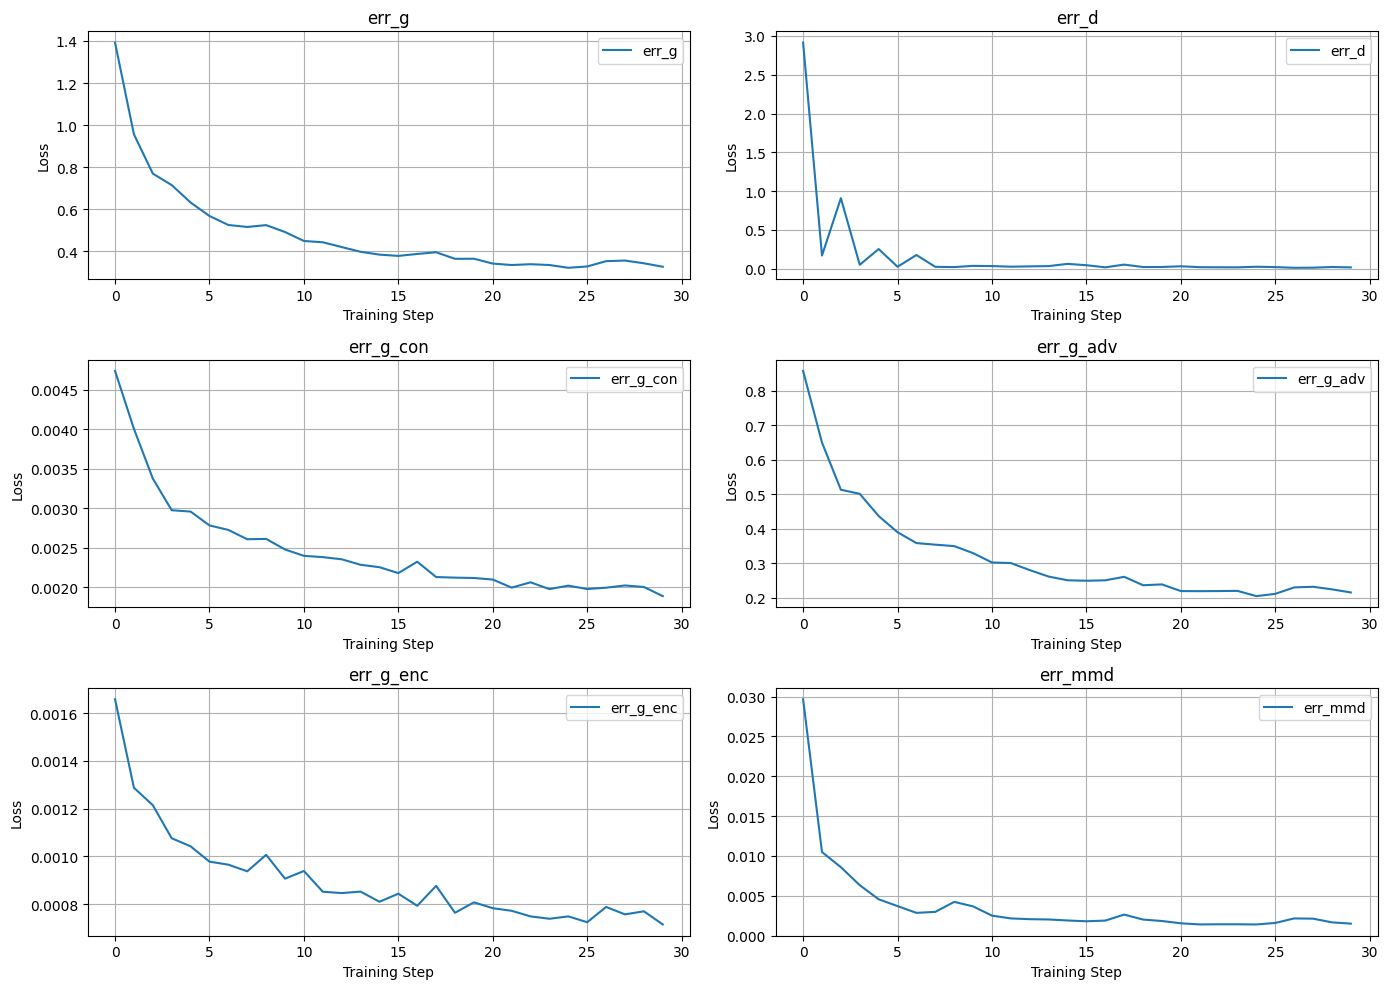

In [33]:
import matplotlib.pyplot as plt

def plot_all_losses_subplots(all_losses):
    loss_names = list(all_losses.keys())
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, loss_name in enumerate(loss_names):
        axes[idx].plot(all_losses[loss_name], label=loss_name)
        axes[idx].set_title(f'{loss_name}')
        axes[idx].set_xlabel('Training Step')
        axes[idx].set_ylabel('Loss')
        axes[idx].grid(True)
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

plot_all_losses_subplots(all_losses)

## Zero-Shot

### Threshold Updating

In [36]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

# === Step 1: Split into 20% (for threshold) and 80% (for final testing)
indices = list(range(len(full_dataset)))
threshold_idx, test_idx = train_test_split(
    indices, test_size=0.8, stratify=full_dataset.labels, random_state=42
)

threshold_set = Subset(full_dataset, threshold_idx)
test_set = Subset(full_dataset, test_idx)

threshold_loader = DataLoader(threshold_set, batch_size=opt.batchsize, shuffle=False)
test_loader = DataLoader(test_set, batch_size=opt.batchsize, shuffle=False)

lungan = GANLung(opt)
lungan.load_model(load_path)
lungan.seed(opt.seed)  # Optional but reproducible

tester = GANTester(lungan, threshold_loader, test_loader, lungan.device)
tester.alpha = 0.8

# Use the 20% for threshold calibration
best_thresholds = tester.get_threshold_precision_recall(threshold_loader)

# Evaluate on the 80%
metrics, y_true, scores = tester.test()
classification_results, y_pred = tester.calculate_classification_metrics(
    best_thresholds, metrics, y_true=y_true, scores=scores
)

df_results = format_metrics(classification_results)
df_results


,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,3,23,3,16,0.115385,0.842105,0.410256,0.551724,0.643725
1,sum,6,20,3,16,0.230769,0.842105,0.444444,0.581818,0.651822


### No Threshold Updating

In [15]:
import importlib
import models.latstats.network
import models.base.network
import models.morph.network
import models.sobel.network
import config.options
importlib.reload(models.latstats.network)
importlib.reload(models.base.network)
importlib.reload(models.morph.network)
importlib.reload(models.sobel.network)
importlib.reload(config.options)
from train.test import GANTester

from config.options import Options
opt = Options().parse()

from models.morph.network import GANLung  

load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"

LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

def format_metrics(metrics_dict):
    # Create a list to hold the rows of the table
    rows = []
    
    # Collect the data for each model and metric, excluding 'latent'
    for model, metrics in metrics_dict.items():
        if model == "latent":
            continue  # Skip the 'latent' model
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    
    # Create a DataFrame from the collected rows
    df = pd.DataFrame(rows)
    
    return df


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
tester = GANTester(LunGAN, train_loader, test_hist, LunGAN.device)
tester.alpha = 0.8
best_thresholds = tester.get_threshold_precision_recall(train_loader)
metrics, y_true, scores_dict = tester.test()
classification_results, y_pred_t = tester.calculate_classification_metrics(best_thresholds, metrics, y_true=y_true, scores=scores_dict)
# plot_classification_metrics(classification_results)
# plot_confusion_matrix(y_true, y_pred, title='Test Set Confusion Matrix')
format_metrics(classification_results)

,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,15,17,7,17,0.46875,0.708333,0.500000,0.586207,0.606771
1,sum,15,17,8,16,0.46875,0.666667,0.484848,0.561404,0.613281


### Reconstructions plotting

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reconstructions(real_images, reconstructed_images, labels, predictions=None, indices=None, n=5, title="Real vs Reconstructed"):
    """
    Plot original and reconstructed images side by side.
    """
    if indices is None:
        indices = range(n)
    
    plt.figure(figsize=(4 * n, 4))
    
    for i, idx in enumerate(indices):
        real = real_images[idx].squeeze()
        recon = reconstructed_images[idx].squeeze()
        
        plt.subplot(2, n, i + 1)
        plt.imshow(real, cmap='gray')
        true_label = labels[idx]
        pred_label = predictions[idx] if predictions is not None else "?"
        plt.title(f"Real\nTrue: {true_label} | Pred: {pred_label}")
        plt.axis('off')

        plt.subplot(2, n, n + i + 1)
        plt.imshow(recon, cmap='gray')
        plt.title(f"Reconstructed")
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from operator import itemgetter

# Convert your data into numpy arrays
y_true = np.array(tester.labels)
y_pred = np.array(y_pred_t["mse"]) 
scores = np.array(scores_dict["mse"])

# Group and sort by score
group_indices = {
    "TP": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 1],
    "TN": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 0],
    "FP": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 1],
    "FN": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 0],
}

def interactive_reconstruction_viewer(group="FP", ascending=True):
    indices = group_indices[group]

    if not indices:
        print(f"No samples in group: {group}")
        return

    # Sort indices by score
    sorted_indices = sorted(indices, key=lambda i: scores[i], reverse=not ascending)
    n = len(sorted_indices)

    slider = widgets.IntSlider(value=0, min=0, max=n - 1, step=1, description=f"{group} Index")

    def plot_sample(i):
        idx = sorted_indices[i]
        real_img = tester.real_images[idx].squeeze()
        recon_img = tester.generated_images[idx].squeeze()
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        score_val = scores[idx]

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(real_img, cmap='gray')
        plt.title(f"Real (True={true_label})")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(recon_img, cmap='gray')
        plt.title(f"Reconstructed (Pred={pred_label})")
        plt.axis("off")

        plt.suptitle(f"{group} | Index {idx} | Score = {score_val:.4f}", fontsize=14)
        plt.tight_layout()
        plt.show()

    widgets.interact(plot_sample, i=slider)

# 👉 Use like this:
interactive_reconstruction_viewer("TN", ascending=True)  # You can change to TP, TN, FN


: 

: 

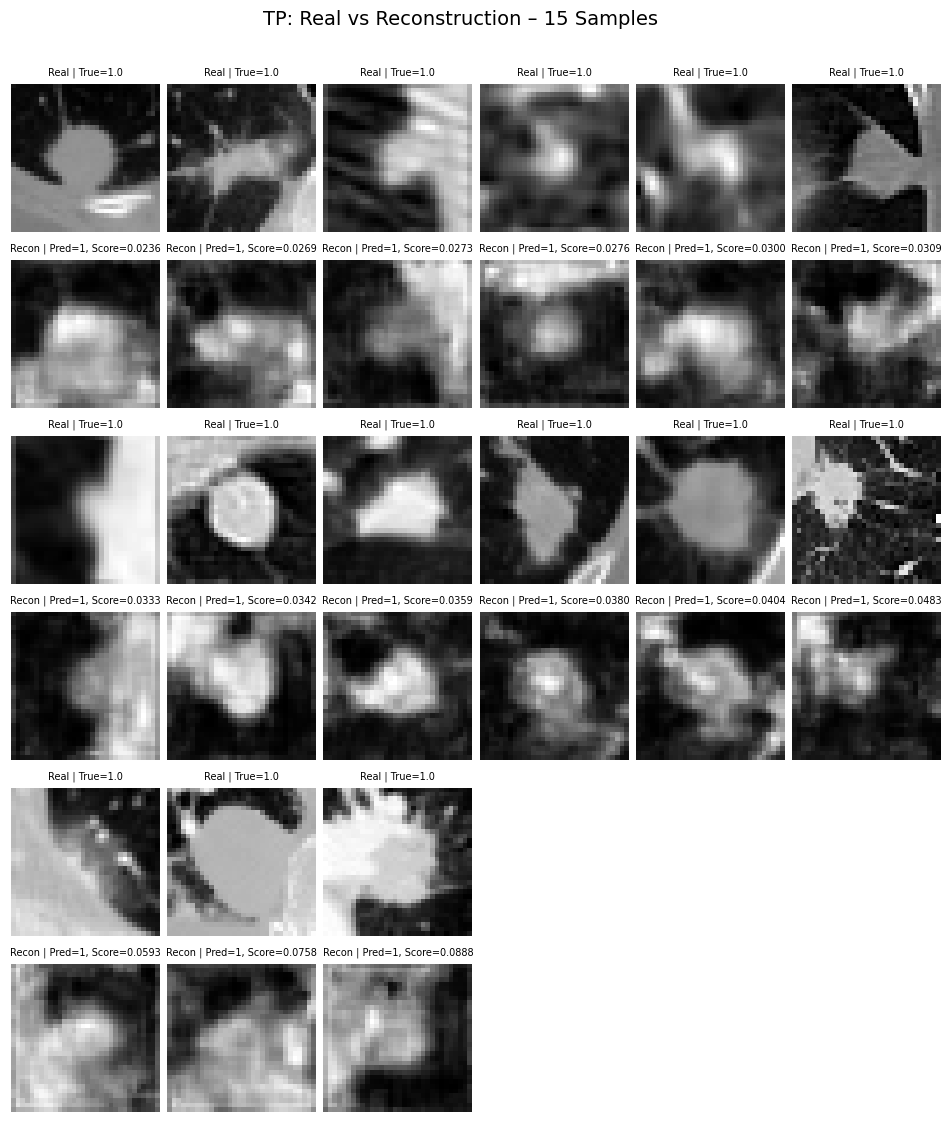

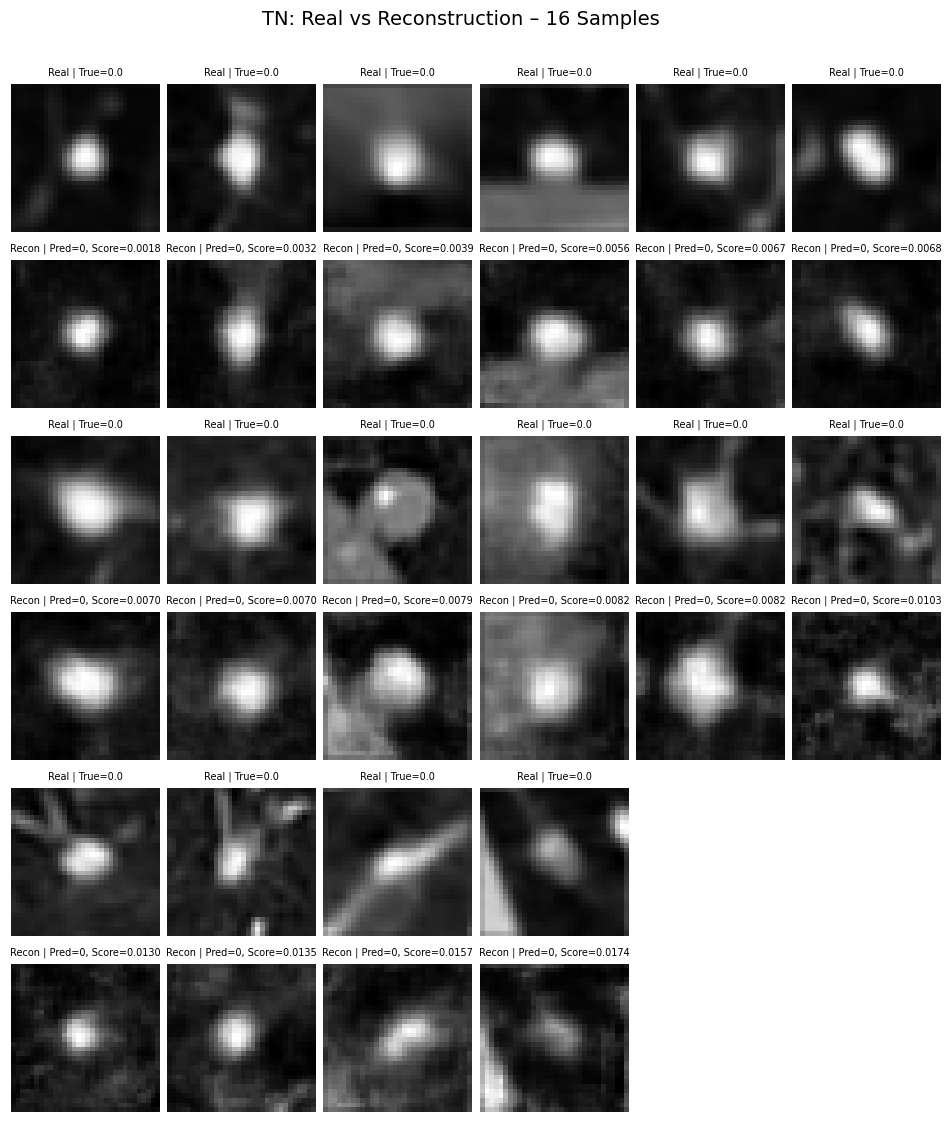

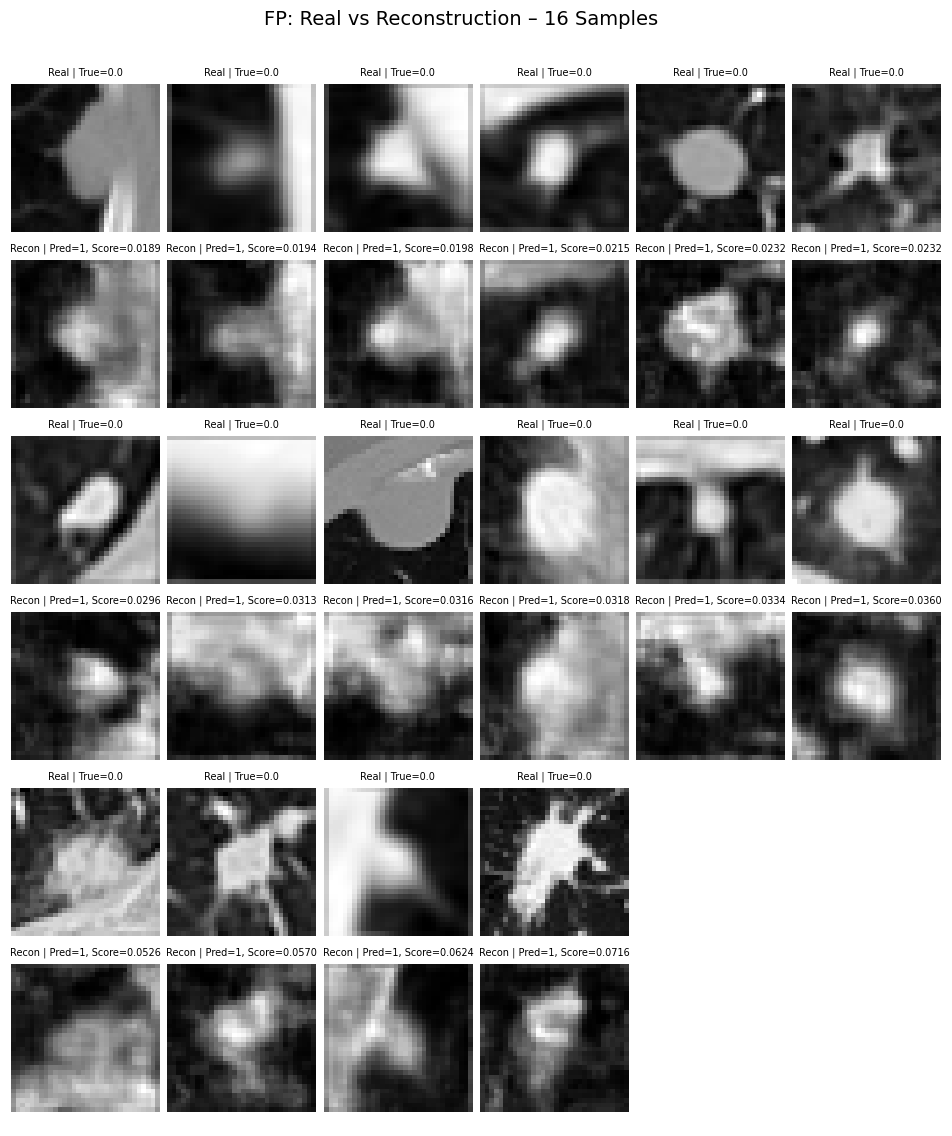

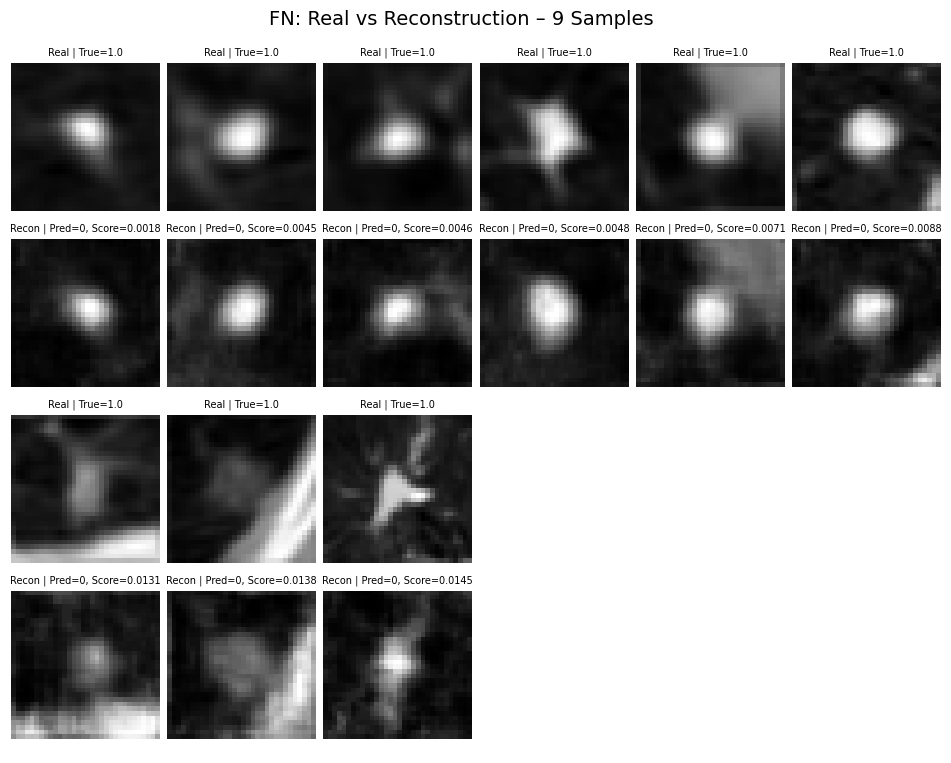

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

import matplotlib.pyplot as plt
import numpy as np
import math

def plot_full_group_grid_fixed_tight(
    group,
    y_true, y_pred, scores,
    real_images, recon_images,
    ascending=True,
    images_per_row=6
):
    group_indices = {
        "TP": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 1],
        "TN": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 0],
        "FP": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 1],
        "FN": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 0],
    }

    indices = group_indices[group]
    if not indices:
        print(f"No samples found for group: {group}")
        return

    sorted_indices = sorted(indices, key=lambda i: scores[i], reverse=not ascending)

    n = len(sorted_indices)
    n_cols = images_per_row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(2 * n_rows, n_cols, figsize=(n_cols * 2, n_rows * 4),
                             gridspec_kw=dict(wspace=0.05, hspace=0.0))

    axes = np.array(axes).reshape(2 * n_rows, n_cols)

    for ax in axes.flatten():
        ax.axis("off")

    for plot_idx, idx in enumerate(sorted_indices):
        row = plot_idx // n_cols
        col = plot_idx % n_cols

        real = real_images[idx].squeeze()
        recon = recon_images[idx].squeeze()
        true = y_true[idx]
        pred = y_pred[idx]
        score = scores[idx]

        ax_real = axes[row * 2][col]
        ax_recon = axes[row * 2 + 1][col]

        ax_real.imshow(real, cmap="gray")
        ax_real.set_title(f"Real | True={true}", fontsize=7)
        ax_real.axis("off")

        ax_recon.imshow(recon, cmap="gray")
        ax_recon.set_title(f"Recon | Pred={pred}, Score={score:.4f}", fontsize=7)
        ax_recon.axis("off")

    plt.suptitle(f"{group}: Real vs Reconstruction – {n} Samples", fontsize=14)
    plt.subplots_adjust(top=0.93, bottom=0.05)
    plt.show()


# Call for each group
plot_full_group_grid_fixed_tight("TP", y_true, y_pred, scores, tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("TN", y_true, y_pred, scores, tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("FP", y_true, y_pred, scores, tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("FN", y_true, y_pred, scores, tester.real_images, tester.generated_images)


### Feature extraction for Hist TSNE Plotting

In [40]:
import numpy as np

features = np.array([x.flatten() for x in tester.latent_outputs])

y_true = np.array(y_true)
y_pred = np.array(y_pred_t["mse"])

conditions = []


for true, pred in zip(y_true, y_pred):
    if true == 1 and pred == 1:
        conditions.append("TP")
    elif true == 0 and pred == 0:
        conditions.append("TN")
    elif true == 0 and pred == 1:
        conditions.append("FP")
    elif true == 1 and pred == 0:
        conditions.append("FN")


#### Color by Malignancy

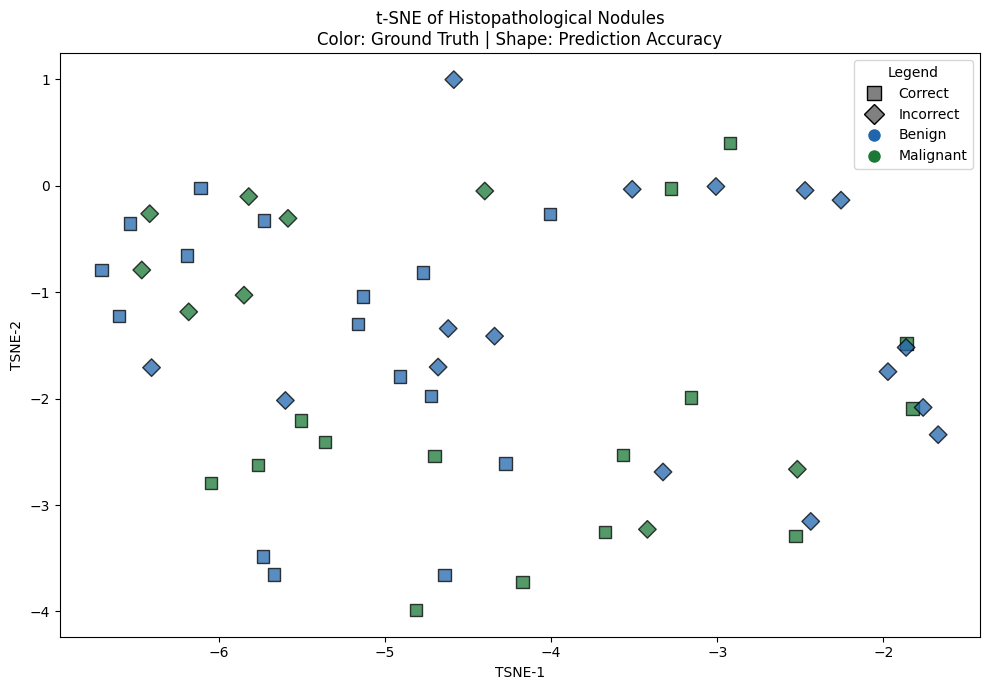

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# ---------- Assume you already have ----------
# features (N, latent_dim)
# y_true, y_pred (both lists or arrays)
# These must all align with each other in length!

# --- Run t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(features)

# --- Build DataFrame ---
tsne_df = pd.DataFrame({
    "TSNE-1": tsne_result[:, 0],
    "TSNE-2": tsne_result[:, 1],
    "True": y_true,
    "Pred": y_pred
})

# --- Add Ground Truth and Correctness info ---
tsne_df["GroundTruth"] = tsne_df["True"].map({0: "Benign", 1: "Malignant"})
tsne_df["Correct"] = tsne_df.apply(lambda row: "Correct" if row["True"] == row["Pred"] else "Incorrect", axis=1)

# --- Assign Color by Ground Truth ---
tsne_df["Color"] = tsne_df["GroundTruth"].map({
    "Benign": "#2166ac",     # blue
    "Malignant": "#1b7837"   # green
})

# --- Assign Marker by Correctness ---
tsne_df["Marker"] = tsne_df["Correct"].map({
    "Correct": "s",     # square
    "Incorrect": "D"    # diamond
})

# --- Plot ---
plt.figure(figsize=(10, 7))

# Plot each marker shape separately
for marker_type in ["s", "D"]:
    subset = tsne_df[tsne_df["Marker"] == marker_type]
    label = "Correct" if marker_type == "s" else "Incorrect"
    
    plt.scatter(
        subset["TSNE-1"], subset["TSNE-2"],
        c=subset["Color"],
        marker=marker_type,
        edgecolor='k',
        s=80,
        label=label,
        alpha=0.75
    )

# --- Custom Legend ---
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', label='Correct', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='D', color='w', label='Incorrect', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor='#2166ac', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor='#1b7837', markersize=10)
]
plt.legend(handles=legend_handles, title="Legend")

plt.title("t-SNE of Histopathological Nodules\nColor: Ground Truth | Shape: Prediction Accuracy")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.tight_layout()
plt.show()


#### Color by Spiculation

In [7]:
from sklearn.metrics import silhouette_score

# Use original latent space, not t-SNE output
score = silhouette_score(features, y_true)  # or y_pred
print(f"Silhouette Score (GT labels): {score:.4f}")

from scipy.spatial.distance import cdist

benign = features[np.array(y_true) == 0]
malignant = features[np.array(y_true) == 1]

# Mean intra-class distance
intra_benign = np.mean(cdist(benign, benign))
intra_malignant = np.mean(cdist(malignant, malignant))

# Mean inter-class distance
inter_class = np.mean(cdist(benign, malignant))

print(f"Intra Benign: {intra_benign:.4f}")
print(f"Intra Malignant: {intra_malignant:.4f}")
print(f"Inter-class Distance: {inter_class:.4f}")

from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(features, y_true)
print(f"Davies-Bouldin Index: {db_index:.4f}")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)
acc = cross_val_score(knn, features, y_true, cv=5).mean()

print(f"kNN Accuracy in Latent Space: {acc:.4f}")


Silhouette Score (GT labels): 0.0060
Intra Benign: 0.2821
Intra Malignant: 0.3007
Inter-class Distance: 0.3026
Davies-Bouldin Index: 6.8558
kNN Accuracy in Latent Space: 0.3530


PCA Explained Variance: PC1 = 14.60%, PC2 = 13.13%


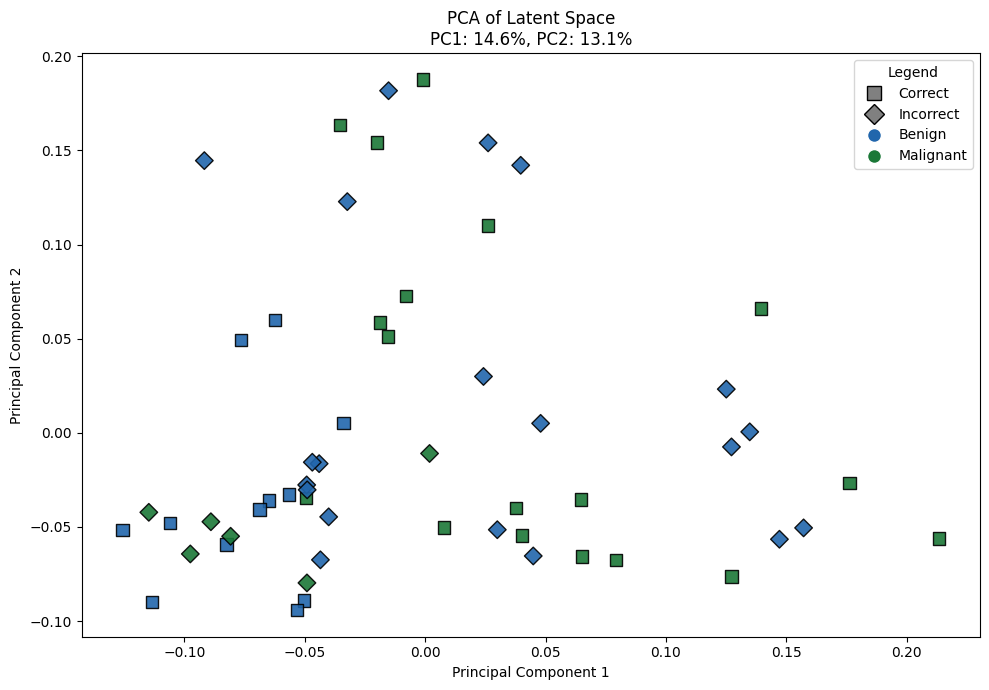

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assume: features, y_true, y_pred are defined

# --- PCA with 2 components ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# --- Explained variance ratio ---
explained = pca.explained_variance_ratio_
print(f"PCA Explained Variance: PC1 = {explained[0]:.2%}, PC2 = {explained[1]:.2%}")

# --- Build DataFrame like t-SNE ---
pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "True": y_true,
    "Pred": y_pred
})
pca_df["GroundTruth"] = ["Benign" if y == 0 else "Malignant" for y in y_true]
pca_df["Correct"] = ["Correct" if t == p else "Incorrect" for t, p in zip(y_true, y_pred)]

# Map color and shape
pca_df["Color"] = pca_df["GroundTruth"].map({
    "Benign": "#2166ac",
    "Malignant": "#1b7837"
})
pca_df["Marker"] = pca_df["Correct"].map({
    "Correct": "s",
    "Incorrect": "D"
})

# --- Plot PCA ---
plt.figure(figsize=(10, 7))

for marker_type in ["s", "D"]:
    subset = pca_df[pca_df["Marker"] == marker_type]
    label = "Correct" if marker_type == "s" else "Incorrect"
    
    plt.scatter(
        subset["PC1"], subset["PC2"],
        c=subset["Color"],
        marker=marker_type,
        edgecolor='k',
        s=80,
        label=label,
        alpha=0.9
    )

# --- Custom Legend ---
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', label='Correct', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='D', color='w', label='Incorrect', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor='#2166ac', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor='#1b7837', markersize=10)
]
plt.legend(handles=legend_handles, title="Legend")

plt.title(f"PCA of Latent Space\nPC1: {explained[0]:.1%}, PC2: {explained[1]:.1%}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


In [43]:
# Predictions for x 
y_pred = y_pred_t['mse']
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Indices
wrong_indices = np.where(y_true != y_pred)[0]
correct_indices = np.where(y_true == y_pred)[0]

# Dataset source (you already have this)
dataset = test_hist.dataset

# All 4 sample groups (file path, true, pred, score)
wrong_samples = [(dataset.nodule_ids[i], y_true[i], y_pred[i], scores_dict['mse'][i]) for i in wrong_indices]
correct_samples = [(dataset.nodule_ids[i], y_true[i], y_pred[i], scores_dict['mse'][i]) for i in correct_indices]

# Sub-classify
fp_samples = [s for s in wrong_samples if s[1] == 0 and s[2] == 1]
fn_samples = [s for s in wrong_samples if s[1] == 1 and s[2] == 0]
tn_samples = [s for s in correct_samples if s[1] == 0 and s[2] == 0]
tp_samples = [s for s in correct_samples if s[1] == 1 and s[2] == 1]

In [44]:
import re

def parse_prediction_samples(samples):
    records = []
    for file_path, true, pred, score in samples:
        filename = os.path.basename(file_path)
        match = re.match(r"(LIDC-IDRI-\d{4})_(\d+)\.npy", filename)
        if match:
            patient_id = match.group(1)
            nodule_number = int(match.group(2))
            records.append({
                "patient_id": patient_id,
                "nodule_number": nodule_number,
                "true_label": int(true),
                "predicted_label": int(pred),
                "score": score
            })
    return pd.DataFrame(records)

In [45]:
# Parse wrong predictions
fp_df = parse_prediction_samples(fp_samples)
fn_df = parse_prediction_samples(fn_samples)
tp_df = parse_prediction_samples(tp_samples)
tn_df = parse_prediction_samples(tn_samples)

# Load all 4 CSVs (modify the paths if needed)
rad4 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/4_radiologists.csv")
rad3 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/3_radiologists.csv")
rad2 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/2_radiologists.csv")
rad1 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/1_radiologists.csv")

# Make sure 'nodule_number' is int for consistency
for df in [rad4, rad3, rad2, rad1]:
    df["nodule_number"] = df["nodule_number"].astype(int)

# Start with the most confident
combined = pd.concat([rad4, rad3, rad2, rad1], ignore_index=True)

# Drop duplicates keeping the first (i.e., prefer 4 > 3 > 2 > 1)
metadata_df = combined.drop_duplicates(subset=["patient_id", "nodule_number"], keep="first")


fp_merged = pd.merge(fp_df, metadata_df, on=["patient_id", "nodule_number"], how="left")
fn_merged = pd.merge(fn_df, metadata_df, on=["patient_id", "nodule_number"], how="left")
tn_merged = pd.merge(tn_df, metadata_df, on=["patient_id", "nodule_number"], how="left")
tp_merged = pd.merge(tp_df, metadata_df, on=["patient_id", "nodule_number"], how="left")

In [46]:
from scipy.stats import ttest_ind

features = [
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]


# Add condition labels
fp_merged["Condition"] = "False Positive"
fn_merged["Condition"] = "False Negative"
tn_merged["Condition"] = "True Negative"
tp_merged["Condition"] = "True Positive"

# Combine all into one
all_merged = pd.concat([fp_merged, fn_merged, tn_merged, tp_merged], ignore_index=True)

from scipy.stats import ttest_ind
from itertools import combinations

features = [
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]

conditions = ["True Positive", "False Positive", "True Negative", "False Negative"]

# Group the data
grouped = {cond: all_merged[all_merged["Condition"] == cond] for cond in conditions}

# Run t-tests for each feature between each pair of groups
results = []

for feat in features:
    for cond1, cond2 in combinations(conditions, 2):
        group1 = grouped[cond1][feat].dropna()
        group2 = grouped[cond2][feat].dropna()
        
        if len(group1) > 1 and len(group2) > 1:
            t, p = ttest_ind(group1, group2, equal_var=False)
            results.append({
                "Feature": feat,
                "Group 1": cond1,
                "Group 2": cond2,
                "p-value": p
            })

# Convert to DataFrame
import pandas as pd
ttest_df = pd.DataFrame(results)


/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [47]:
print("Mean spiculation:")
print("  TP:", tp_merged["spiculation"].mean())
print("  FN:", fn_merged["spiculation"].mean())


Mean spiculation:
  TP: 1.6
  FN: 1.7777777777777777


In [48]:
from IPython.display import display
display(ttest_df.sort_values(by="p-value"))

,Feature,Group 1,Group 2,p-value
8,calcification,True Positive,False Negative,0.082418
38,texture,True Positive,False Negative,0.110288
20,margin,True Positive,False Negative,0.142963
23,margin,True Negative,False Negative,0.160527
10,calcification,False Positive,False Negative,0.163876
36,texture,True Positive,False Positive,0.169940
41,texture,True Negative,False Negative,0.188137
17,sphericity,True Negative,False Negative,0.268875
7,calcification,True Positive,True Negative,0.278454
2,subtlety,True Positive,False Negative,0.314968


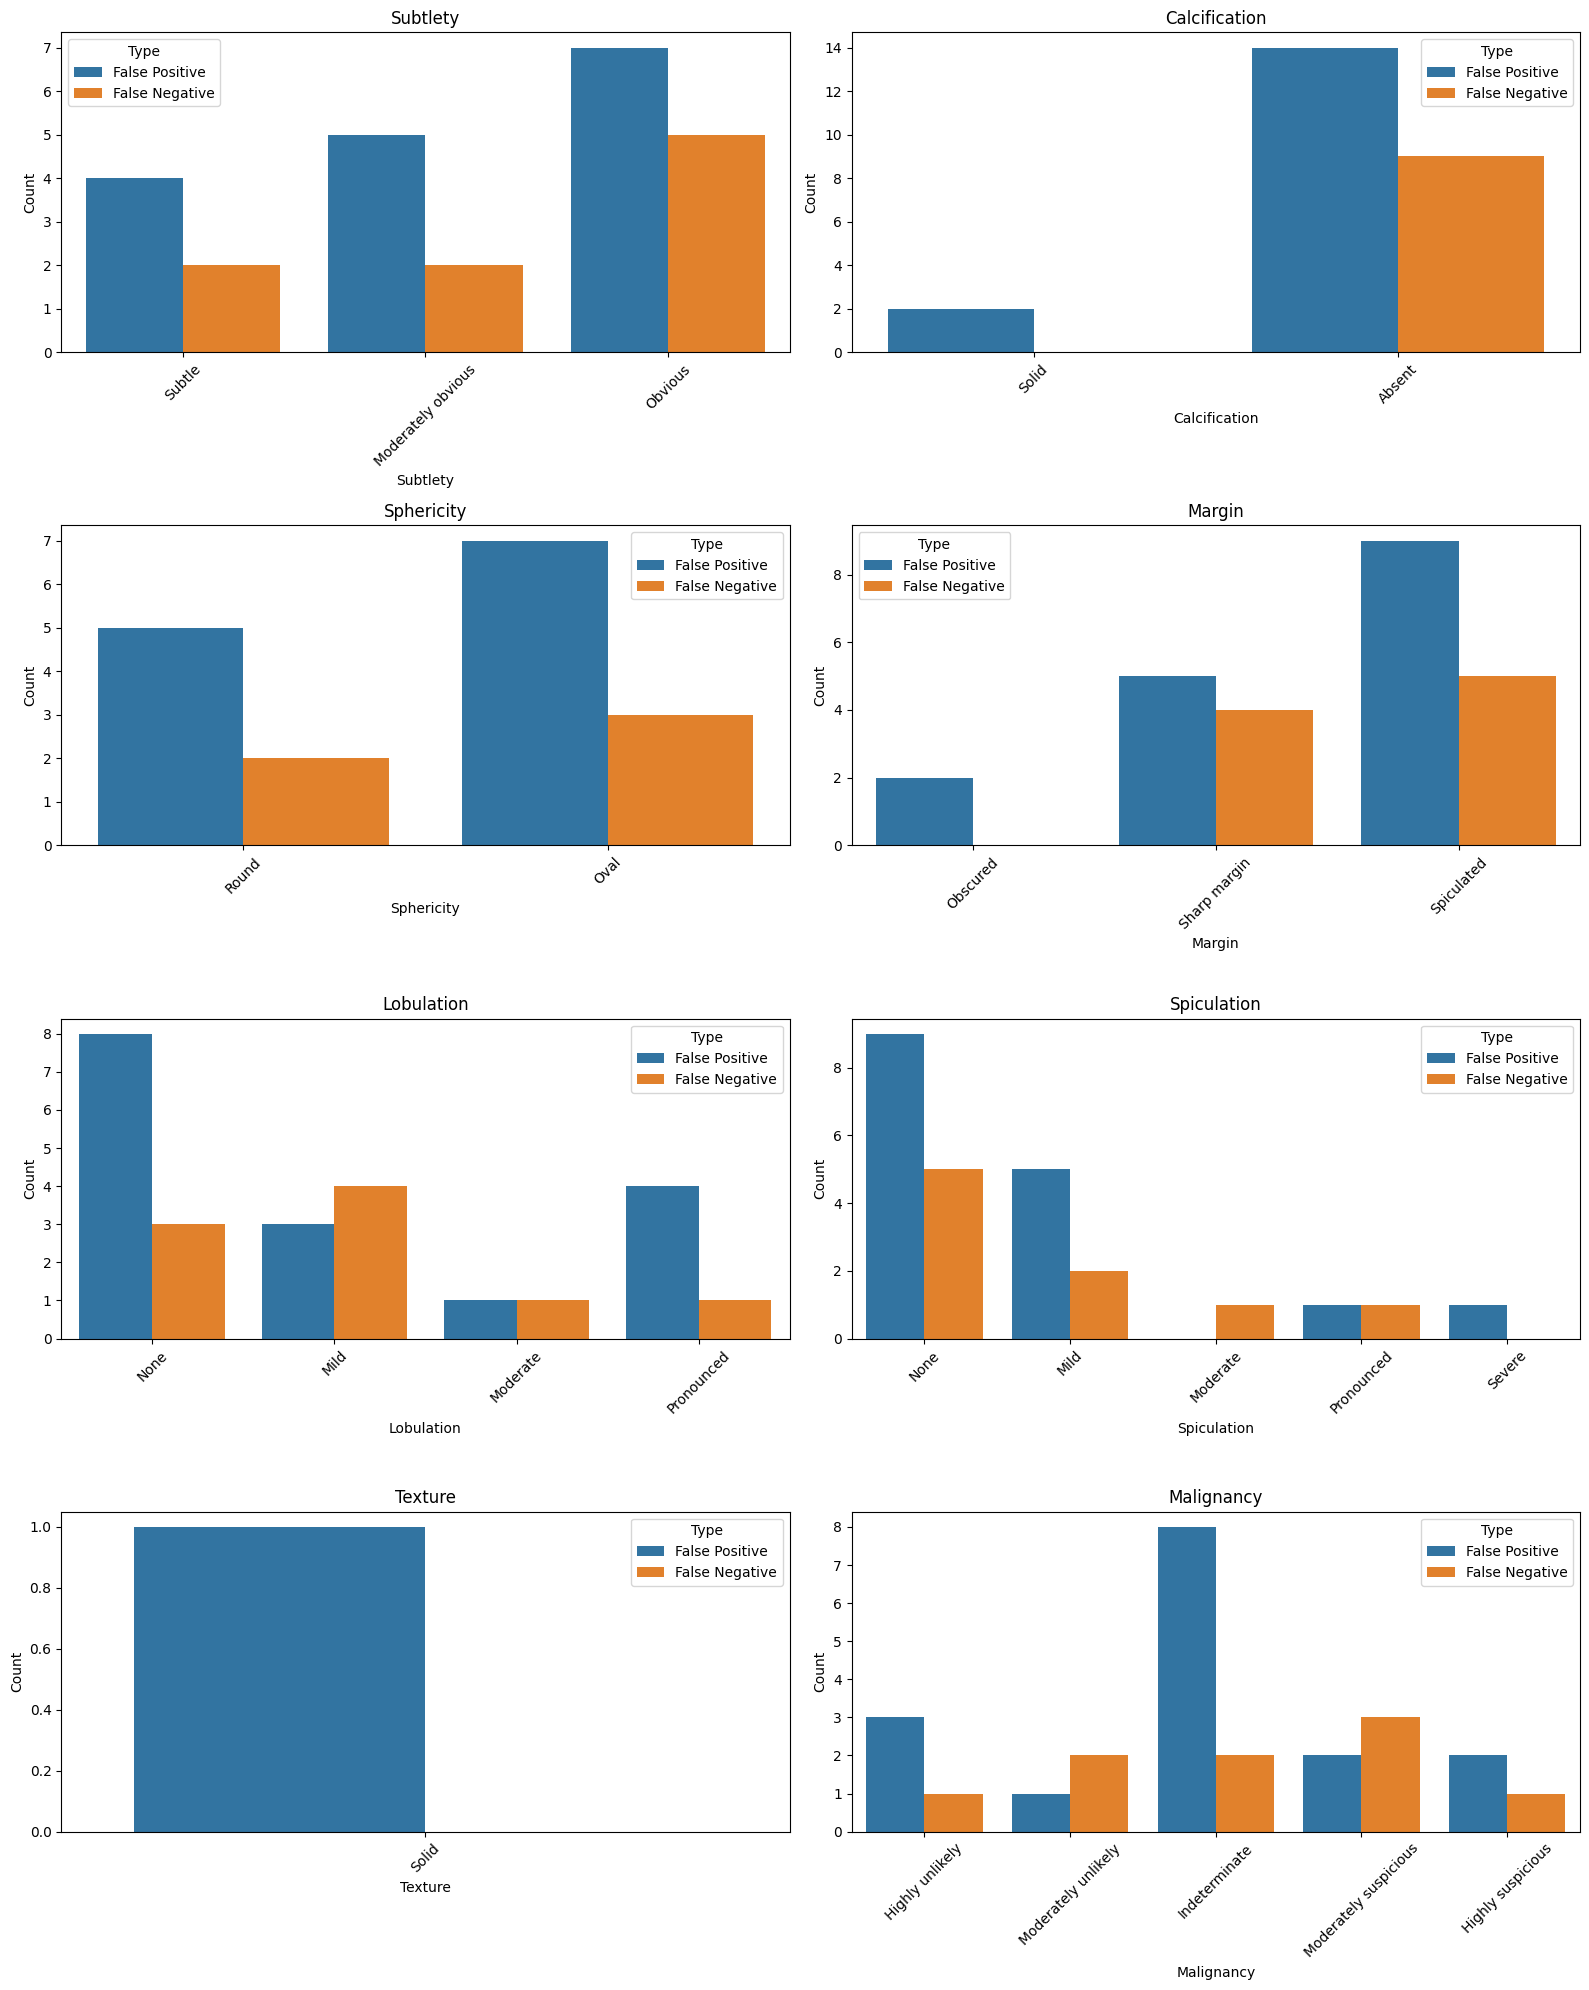

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define label mappings
feature_label_maps = {
    "subtlety": {
        1: "Extremely subtle",
        2: "Very subtle",
        3: "Subtle",
        4: "Moderately obvious",
        5: "Obvious"
    },
    "calcification": {
        1: "Popcorn",
        2: "Laminated",
        3: "Solid",
        4: "Non-central",
        5: "Central",
        6: "Absent"
    },
    "sphericity": {
        1: "Linear",
        2: "Polygonal",
        3: "Round",
        4: "Oval"
    },
    "margin": {
        1: "Poorly defined",
        2: "Obscured",
        3: "Poorly marginated",
        4: "Sharp margin",
        5: "Spiculated"
    },
    "lobulation": {
        1: "None",
        2: "Mild",
        3: "Moderate",
        4: "Pronounced",
        5: "Severe"
    },
    "spiculation": {
        1: "None",
        2: "Mild",
        3: "Moderate",
        4: "Pronounced",
        5: "Severe"
    },
    "texture": {
        1: "Non-solid",
        2: "Ground glass",
        3: "Mixed",
        4: "Solid"
    },
    "malignancy": {
        1: "Highly unlikely",
        2: "Moderately unlikely",
        3: "Indeterminate",
        4: "Moderately suspicious",
        5: "Highly suspicious"
    }
}

# Features to analyze
features = list(feature_label_maps.keys())

# Setup subplot grid
n_features = len(features)
n_cols = 2
n_rows = (n_features + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    label_map = feature_label_maps[feature]

    # Count values
    fp_counts = fp_merged[feature].value_counts().sort_index()
    fn_counts = fn_merged[feature].value_counts().sort_index()

    # Build DataFrame for plotting
    plot_df = (
        pd.DataFrame({
            "False Positive": fp_counts,
            "False Negative": fn_counts
        })
        .fillna(0)
        .astype(int)
        .stack()
        .reset_index()
    )
    plot_df.columns = [feature, "Type", "Count"]

    # Convert index to readable labels
    plot_df[feature] = plot_df[feature].map(label_map)

    sns.barplot(data=plot_df, x=feature, y="Count", hue="Type", ax=ax)
    ax.set_title(f"{feature.replace('_', ' ').capitalize()}")
    ax.set_xlabel(f"{feature.replace('_', ' ').capitalize()}")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

# Remove any extra subplots if grid is bigger than needed
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


Total False Positives: 16
→ With malignant traits: 16
→ With NO malignant traits: 0


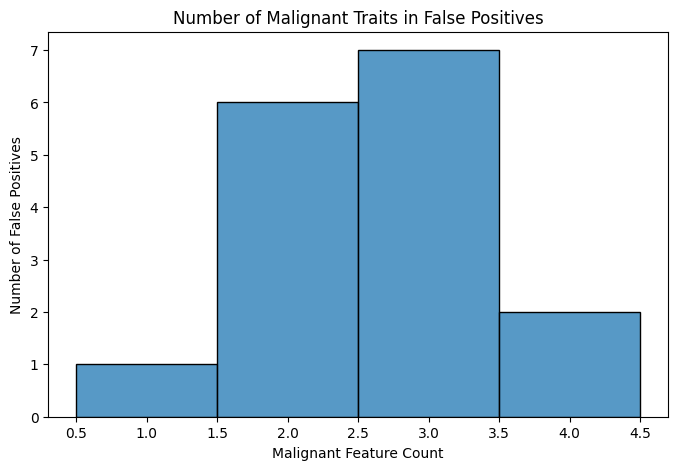

LIDC-IDRI-0090_1: ['Calcification: Absent', 'Sphericity: Oval', 'Margin: Spiculated', 'Lobulation: Moderate']
LIDC-IDRI-0138_1: ['Calcification: Absent', 'Lobulation: Pronounced', 'Spiculation: Pronounced']
LIDC-IDRI-0178_1: ['Calcification: Absent', 'Sphericity: Oval', 'Margin: Spiculated']
LIDC-IDRI-0180_1: ['Calcification: Absent', 'Sphericity: Oval', 'Margin: Sharp margin']
LIDC-IDRI-0183_1: ['Calcification: Absent', 'Sphericity: Oval', 'Margin: Spiculated']
LIDC-IDRI-0185_1: ['Calcification: Absent', 'Margin: Sharp margin']
LIDC-IDRI-0242_1: ['Calcification: Absent', 'Margin: Sharp margin', 'Lobulation: Pronounced', 'Spiculation: Severe']
LIDC-IDRI-0247_1: ['Calcification: Absent', 'Margin: Spiculated']
LIDC-IDRI-0257_1: ['Calcification: Absent', 'Lobulation: Pronounced']
LIDC-IDRI-0277_1: ['Calcification: Absent', 'Margin: Sharp margin']
LIDC-IDRI-0289_2: ['Calcification: Absent', 'Margin: Spiculated']
LIDC-IDRI-0377_1: ['Calcification: Absent', 'Margin: Sharp margin', 'Lobulatio

/tmp/ipykernel_62513/2076083132.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trait_df, x="Trait", y="Count", palette="crest")


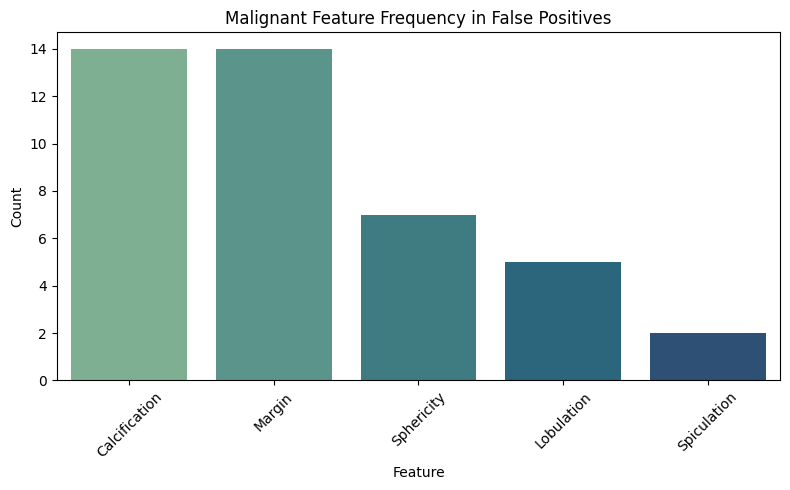

In [50]:
malignant_feature_thresholds = {
    "subtlety": [1, 2],             # Extremely subtle and Very subtle
    "calcification": [6],           # Absent
    "sphericity": [1, 2, 4],        # All but round ones
    "margin": [4, 5],               # Sharp margin, Spiculated
    "lobulation": [3, 4, 5],        # Moderate to Severe
    "spiculation": [3, 4, 5],       # Moderate to Severe
    "texture": [1, 2, 3],           # All but solid ones
}


# Identify which FPs have no malignant features
def has_malignant_feature(row, malignant_thresholds):
    for feature, bad_values in malignant_thresholds.items():
        val = row.get(feature)
        if pd.isna(val):
            continue  # skip if missing
        if val in bad_values:
            return True
    return False

# Apply to false positives
fp_merged["has_malignant_feature"] = fp_merged.apply(
    lambda row: has_malignant_feature(row, malignant_feature_thresholds), axis=1
)

# Get the suspicious ones and the surprising ones
fp_with_malignant_traits = fp_merged[fp_merged["has_malignant_feature"] == True]
fp_without_any_malignant_trait = fp_merged[fp_merged["has_malignant_feature"] == False]

print(f"Total False Positives: {len(fp_merged)}")
print(f"→ With malignant traits: {len(fp_with_malignant_traits)}")
print(f"→ With NO malignant traits: {len(fp_without_any_malignant_trait)}")

def count_malignant_features(row, malignant_thresholds):
    count = 0
    for feature, bad_values in malignant_thresholds.items():
        val = row.get(feature)
        if pd.isna(val):
            continue
        if val in bad_values:
            count += 1
    return count

# Apply to FPs
fp_merged["n_malignant_traits"] = fp_merged.apply(
    lambda row: count_malignant_features(row, malignant_feature_thresholds), axis=1
)

# Histogram of how many malignant traits per FP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(fp_merged["n_malignant_traits"], bins=range(0, 9), discrete=True)
plt.title("Number of Malignant Traits in False Positives")
plt.xlabel("Malignant Feature Count")
plt.ylabel("Number of False Positives")
plt.show()


def get_malignant_features_with_labels(row, malignant_thresholds, label_maps):
    present = []
    for feature, bad_values in malignant_thresholds.items():
        val = row.get(feature)
        if pd.isna(val):
            continue
        if val in bad_values:
            label = label_maps.get(feature, {}).get(val, f"Value {val}")
            present.append(f"{feature.capitalize()}: {label}")
    return present

# Apply to FPs
fp_merged["malignant_features_descriptive"] = fp_merged.apply(
    lambda row: get_malignant_features_with_labels(row, malignant_feature_thresholds, feature_label_maps), axis=1
)

# Print nicely
for _, row in fp_merged.iterrows():
    patient_id = row["patient_id"]
    nodule_number = row["nodule_number"]
    features = row["malignant_features_descriptive"]
    print(f"{patient_id}_{nodule_number}: {features}")


from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature names from "Spiculation: Severe" → "Spiculation"
all_traits = []

for traits in fp_merged["malignant_features_descriptive"]:
    for full_entry in traits:
        feature_name = full_entry.split(":")[0].strip()
        all_traits.append(feature_name)

# Count occurrences
trait_counts = Counter(all_traits)

# Convert to DataFrame
trait_df = pd.DataFrame(trait_counts.items(), columns=["Trait", "Count"])
trait_df = trait_df.sort_values(by="Count", ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=trait_df, x="Trait", y="Count", palette="crest")
plt.title("Malignant Feature Frequency in False Positives")
plt.xlabel("Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
### TN ANALYSIS

Total False Negatives: 9
→ With malignant traits: 9
→ With NO malignant traits: 0


/tmp/ipykernel_62513/282338372.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fn_trait_df, x="Trait", y="Count", palette="flare")


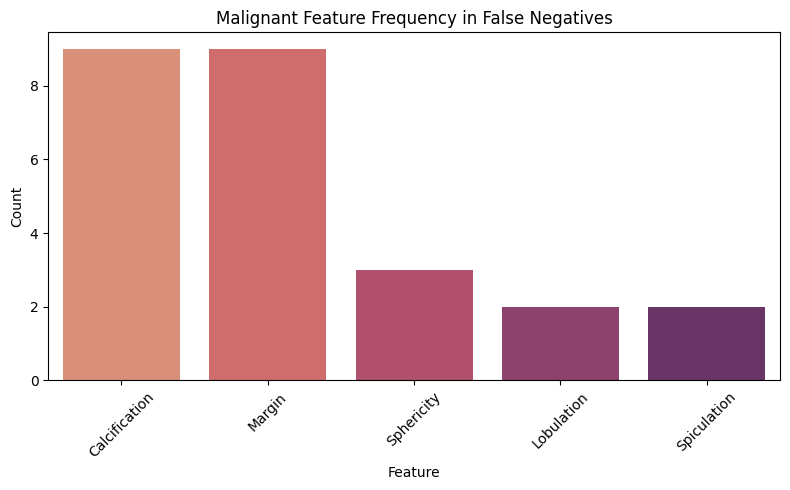

In [51]:
# For FNs: detect which traits were present
fn_merged["has_malignant_feature"] = fn_merged.apply(
    lambda row: has_malignant_feature(row, malignant_feature_thresholds), axis=1
)

fn_merged["n_malignant_traits"] = fn_merged.apply(
    lambda row: count_malignant_features(row, malignant_feature_thresholds), axis=1
)

fn_merged["malignant_features_descriptive"] = fn_merged.apply(
    lambda row: get_malignant_features_with_labels(row, malignant_feature_thresholds, feature_label_maps), axis=1
)

fn_with_malignant_traits = fn_merged[fn_merged["has_malignant_feature"] == True]
fn_without_any_malignant_trait = fn_merged[fn_merged["has_malignant_feature"] == False]

print(f"Total False Negatives: {len(fn_merged)}")
print(f"→ With malignant traits: {len(fn_with_malignant_traits)}")
print(f"→ With NO malignant traits: {len(fn_without_any_malignant_trait)}")

# From fn_merged["malignant_features_descriptive"]
fn_trait_list = []

for traits in fn_merged["malignant_features_descriptive"]:
    for full_entry in traits:
        feature_name = full_entry.split(":")[0].strip()
        fn_trait_list.append(feature_name)

# Count and plot
from collections import Counter
fn_trait_counts = Counter(fn_trait_list)

fn_trait_df = pd.DataFrame(fn_trait_counts.items(), columns=["Trait", "Count"])
fn_trait_df = fn_trait_df.sort_values(by="Count", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=fn_trait_df, x="Trait", y="Count", palette="flare")
plt.title("Malignant Feature Frequency in False Negatives")
plt.xlabel("Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


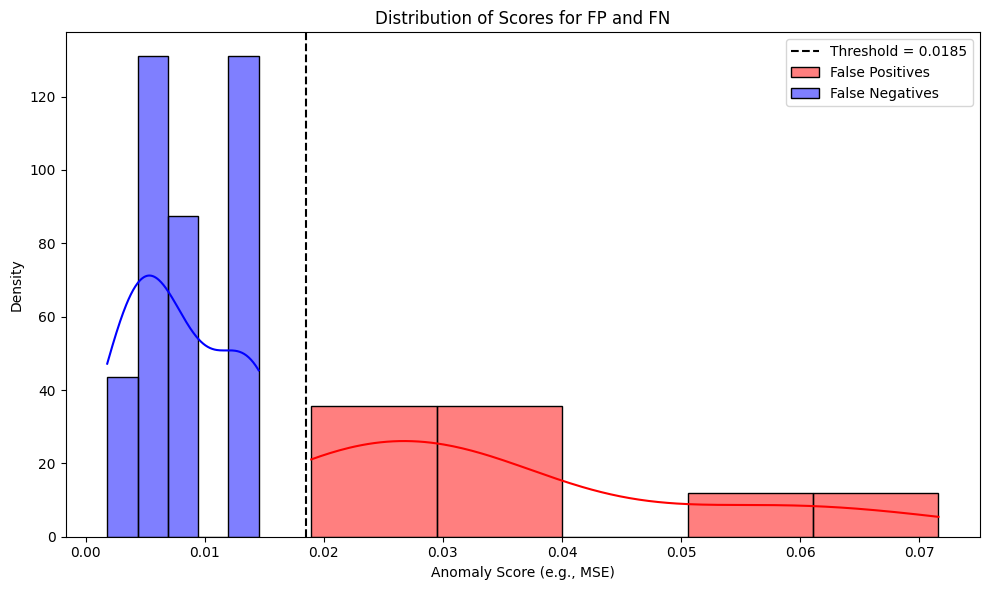

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to arrays
scores = np.array(scores)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Get the threshold you used
threshold = best_thresholds["mse"]  # or "sum" / "latent" depending on your metric

# Masks for each group
fp_mask = (y_true == 0) & (y_pred == 1)
fn_mask = (y_true == 1) & (y_pred == 0)
tp_mask = (y_true == 1) & (y_pred == 1)
tn_mask = (y_true == 0) & (y_pred == 0)

# Create plot
plt.figure(figsize=(10, 6))
sns.histplot(scores[fp_mask], color="red", label="False Positives", kde=True, stat="density")
sns.histplot(scores[fn_mask], color="blue", label="False Negatives", kde=True, stat="density")
# Optional: include TP/TN for full picture
# sns.histplot(scores[tp_mask], color="green", label="True Positives", kde=True, stat="density")
# sns.histplot(scores[tn_mask], color="gray", label="True Negatives", kde=True, stat="density")

# Threshold line
plt.axvline(threshold, color='black', linestyle='--', label=f"Threshold = {threshold:.4f}")

plt.title("Distribution of Scores for FP and FN")
plt.xlabel("Anomaly Score (e.g., MSE)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


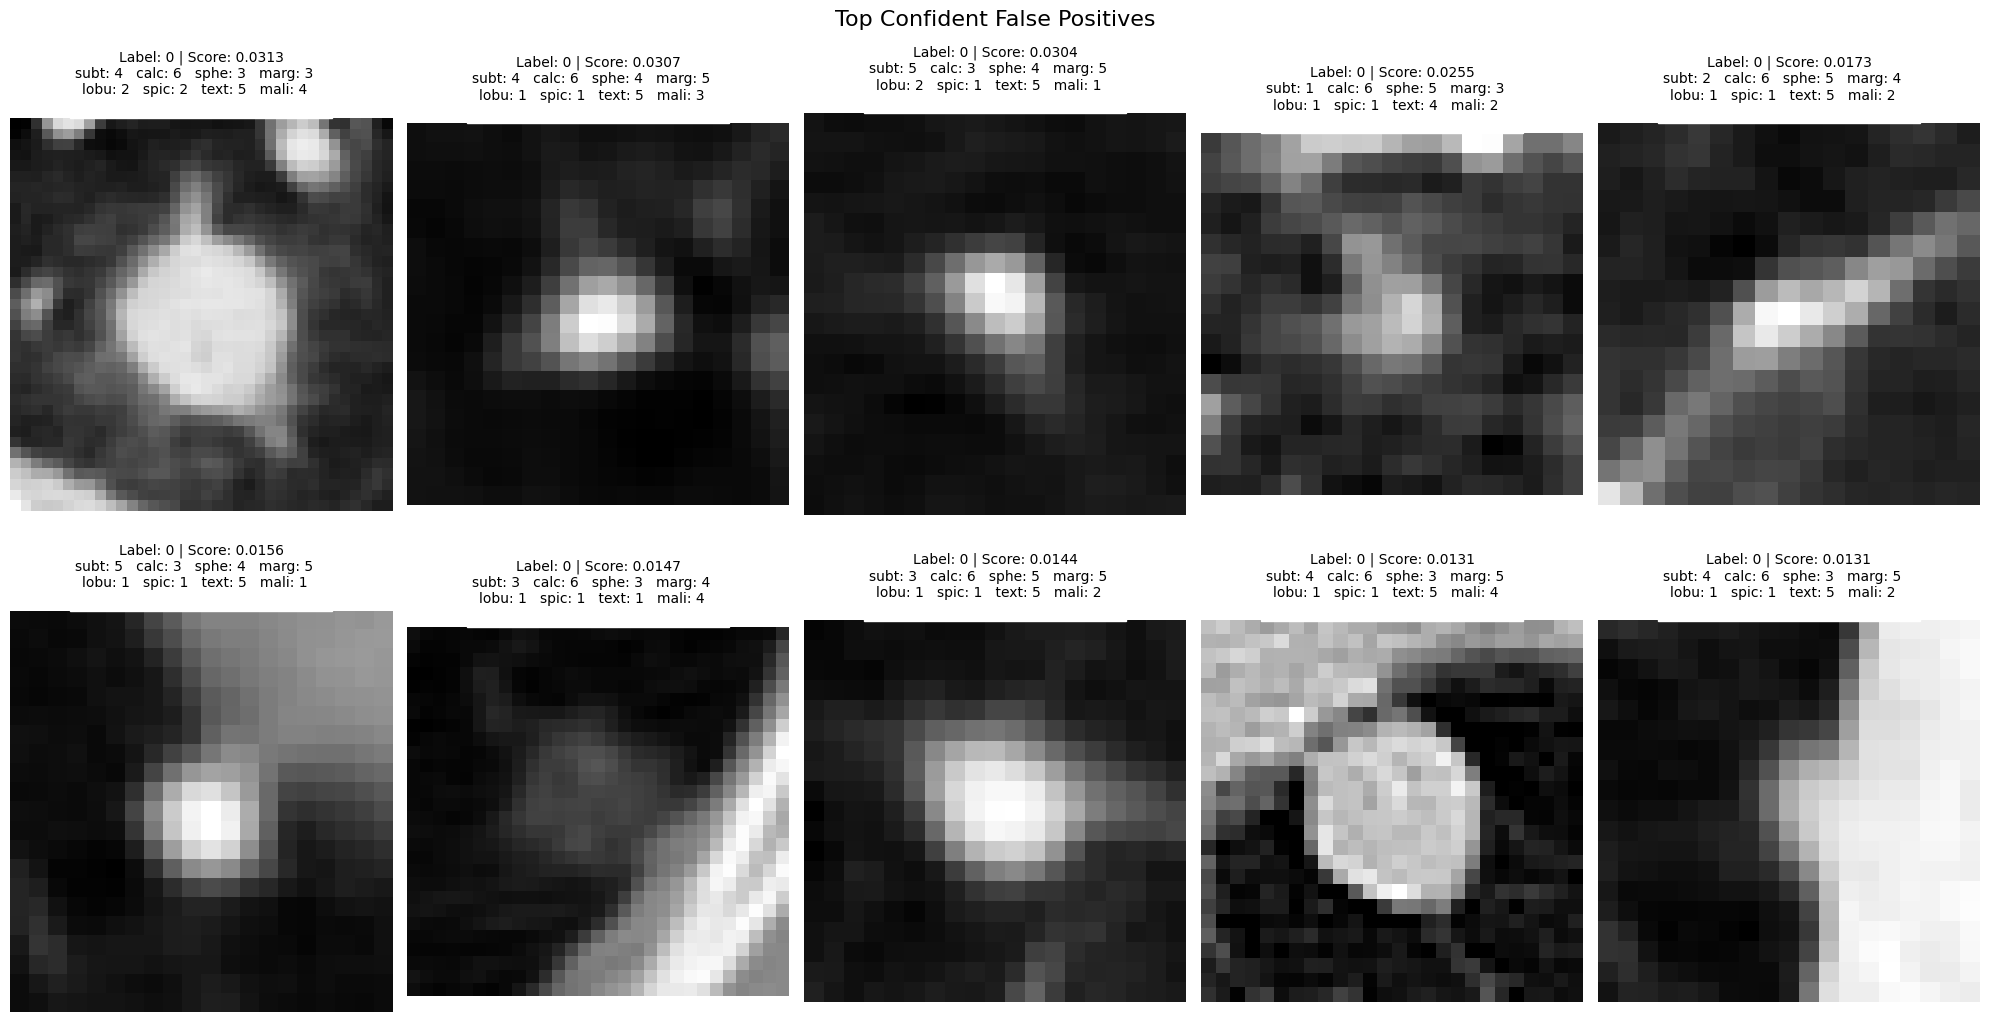

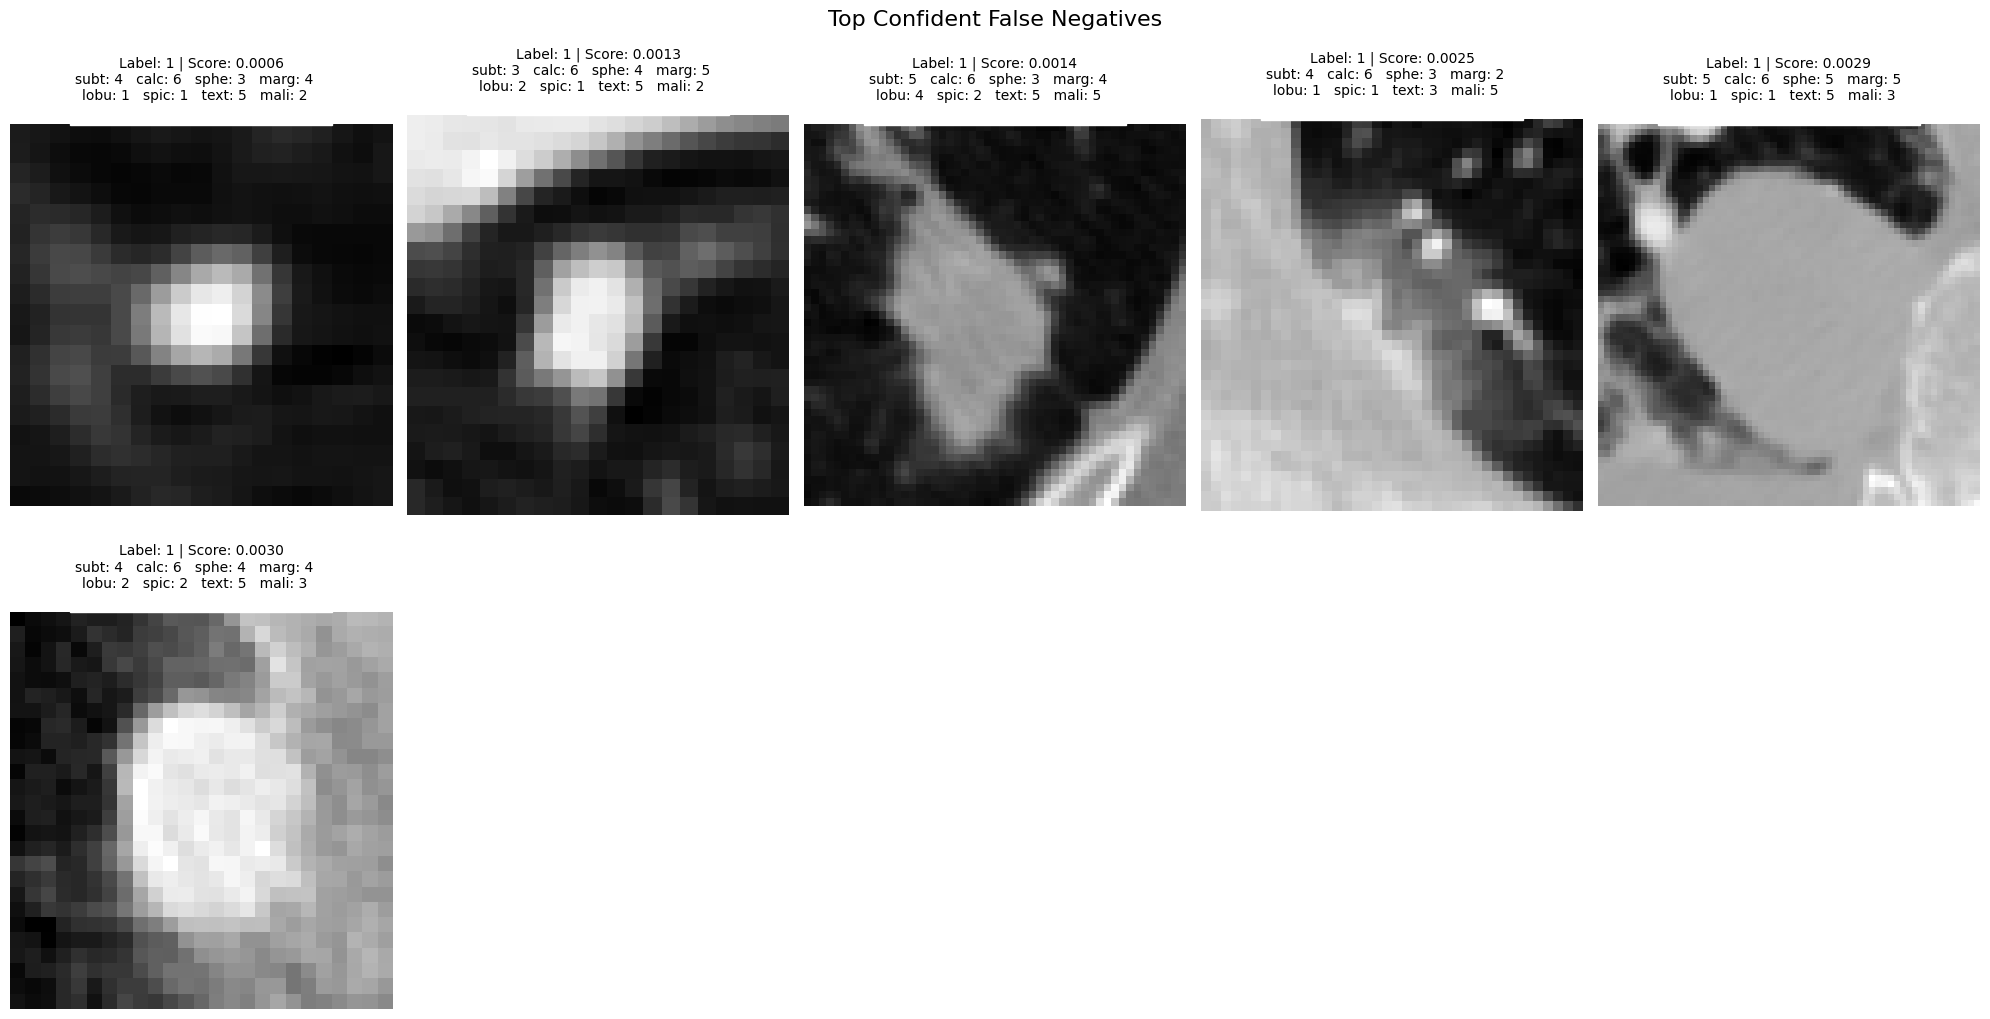

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

# Number of top samples to display
top_n = 10

# === Step 1: Extract patient_id and nodule number from path ===
def extract_patient_info(path):
    filename = os.path.basename(path)
    match = re.match(r"(LIDC-IDRI-\d{4})_(\d+)\.npy", filename)
    if match:
        return match.group(1), int(match.group(2))
    return None, None

# === Step 2: Build the confident misclassification DataFrame ===
scores = np.array(scores)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

fp_indices = np.where((y_true == 0) & (y_pred == 1))[0]
fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]

confident_errors = []

# False Positives
for i in fp_indices:
    path = test_hist.dataset.nodule_ids[i]
    pid, nid = extract_patient_info(path)
    confident_errors.append({
        "Type": "False Positive",
        "File": path,
        "Patient ID": pid,
        "Nodule #": nid,
        "True_Label": int(y_true[i]),
        "Pred_Label": int(y_pred[i]),
        "Score": scores[i]
    })

# False Negatives
for i in fn_indices:
    path = test_hist.dataset.nodule_ids[i]
    pid, nid = extract_patient_info(path)
    confident_errors.append({
        "Type": "False Negative",
        "File": path,
        "Patient ID": pid,
        "Nodule #": nid,
        "True_Label": int(y_true[i]),
        "Pred_Label": int(y_pred[i]),
        "Score": scores[i]
    })

conf_df = pd.DataFrame(confident_errors)

# === Step 3: Merge metadata (exclude internal_structure) ===
features_to_include = [
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]

# Ensure columns align for merging
metadata_df["nodule_number"] = metadata_df["nodule_number"].astype(int)

conf_df = pd.merge(
    conf_df,
    metadata_df[["patient_id", "nodule_number"] + features_to_include],
    left_on=["Patient ID", "Nodule #"],
    right_on=["patient_id", "nodule_number"],
    how="left"
)

# === Step 4: Select top-N from FP and FN (no overlap) ===
fp_df = conf_df[conf_df["Type"] == "False Positive"].sort_values(by="Score", ascending=False)
fn_df = conf_df[conf_df["Type"] == "False Negative"].sort_values(by="Score", ascending=True)

# Ensure no overlap between FP and FN sets
fp_files = set(fp_df["File"])
fn_df = fn_df[~fn_df["File"].isin(fp_files)]

# Take top-N from both
fp_df = fp_df.head(top_n)
fn_df = fn_df.head(top_n)

# === Step 5: Plotting function with features ===
def plot_nodules_with_features(df_subset, title, cols=5):
    n = len(df_subset)
    rows = (n + cols - 1) // cols  # ceil division to determine number of rows
    plt.figure(figsize=(cols * 4, rows * 5.5))

    for i, row in enumerate(df_subset.itertuples()):
        row_dict = row._asdict()
        img = np.load(row_dict["File"])

        label = row_dict["True_Label"]
        score = row_dict["Score"]
        info_text = f"Label: {label} | Score: {score:.4f}\n"

        # Break features into lines
        for j, feat in enumerate(features_to_include):
            val = row_dict.get(feat, "NA")
            info_text += f"{feat[:4]}: {val}   "
            if (j + 1) % 4 == 0:
                info_text += "\n"

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(info_text, fontsize=10, backgroundcolor='white')
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# === Step 6: Plot results ===
plot_nodules_with_features(fp_df, "Top Confident False Positives")
plot_nodules_with_features(fn_df, "Top Confident False Negatives")


In [19]:
import pandas as pd

# Load the uploaded CSV file
df = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/1_radiologists.csv")

# Ensure nodule_number is integer for grouping
df["nodule_number"] = df["nodule_number"].astype(int)

# Count occurrences of each (patient_id, nodule_number) pair
duplicate_counts = (
    df.groupby(["patient_id", "nodule_number"])
    .size()
    .reset_index(name="count")
)

# Filter to only repeated ones
repeated = duplicate_counts[duplicate_counts["count"] > 1]

# Display the repeated values
print("Repeated patient_id + nodule_number combinations:")
print(repeated.sort_values(by="count", ascending=False).to_string(index=False))

Repeated patient_id + nodule_number combinations:
    patient_id  nodule_number  count
LIDC-IDRI-0132              1      2
LIDC-IDRI-0315              5      2
LIDC-IDRI-0484              1      2
LIDC-IDRI-0442              3      2
LIDC-IDRI-0442              2      2
LIDC-IDRI-0442              1      2
LIDC-IDRI-0365              1      2
LIDC-IDRI-0355              1      2
LIDC-IDRI-0332              2      2
LIDC-IDRI-0332              1      2
LIDC-IDRI-0315              4      2
LIDC-IDRI-0132              2      2
LIDC-IDRI-0315              3      2
LIDC-IDRI-0315              2      2
LIDC-IDRI-0315              1      2
LIDC-IDRI-0151              1      2
LIDC-IDRI-0132              6      2
LIDC-IDRI-0132              5      2
LIDC-IDRI-0132              4      2
LIDC-IDRI-0132              3      2
LIDC-IDRI-0484              2      2


In [14]:
# Check for duplicated image files in conf_df
dup_files = conf_df[conf_df.duplicated(subset=["File"], keep=False)]

# Columns to display in the summary
columns_to_show = [
    "File", "Patient ID", "Nodule #", "Score",
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]

# Display the duplicated entries with relevant details
print("Duplicated entries pointing to the same image file (different annotations):")
print(dup_files[columns_to_show].sort_values(by="File").to_string(index=False))


Duplicated entries pointing to the same image file (different annotations):
                                                                               File     Patient ID  Nodule #    Score  subtlety  calcification  sphericity  margin  lobulation  spiculation  texture  malignancy
/home/arumota_pupils/Josue/Datasets/LIDC_Patches/1_radiologist/LIDC-IDRI-0332_1.npy LIDC-IDRI-0332         1 0.030419         5              6           5       3           2            2        4           5
/home/arumota_pupils/Josue/Datasets/LIDC_Patches/1_radiologist/LIDC-IDRI-0332_1.npy LIDC-IDRI-0332         1 0.030419         2              6           4       4           5            5        5           3


In [40]:
fp_files = set(conf_df[conf_df["Type"] == "False Positive"]["File"])
fn_files = set(conf_df[conf_df["Type"] == "False Negative"]["File"])

duplicates = fp_files.intersection(fn_files)
print("Files appearing in both FP and FN:", duplicates)


Files appearing in both FP and FN: set()


# NSCLC Inference

In [4]:
import importlib
import pandas as pd
from torch.utils.data import DataLoader

# Reload your model modules
import models.latstats.network
import models.base.network
import models.morph.network
import models.sobel.network
import config.options
importlib.reload(models.latstats.network)
importlib.reload(models.base.network)
importlib.reload(models.morph.network)
importlib.reload(models.sobel.network)
importlib.reload(config.options)

from train.test import GANTester
from config.options import Options
from models.morph.network import GANLung

# Standard
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from skimage.transform import resize
import glob

# --- NSCLC Dataset Class ---
class NoduleDatasetNSCLC(Dataset):
    def __init__(self, npy_dir):
        self.npy_dir = npy_dir
        self.nodule_files = sorted(
            glob.glob(os.path.join(npy_dir, "*_patch.npy"))
        )
        if not self.nodule_files:
            raise ValueError(f"No '_patch.npy' files found in: {npy_dir}")

    def __len__(self):
        return len(self.nodule_files)

    def __getitem__(self, idx):
        file_path = self.nodule_files[idx]
        npy_data = np.load(file_path)
        npy_data_resized = resize(npy_data, (32, 32), mode='wrap', anti_aliasing=False)
        np_min, np_max = npy_data_resized.min(), npy_data_resized.max()
        if np_max > np_min:
            npy_data_resized = (npy_data_resized - np_min) / (np_max - np_min)
        else:
            npy_data_resized = npy_data_resized - np_min
        npy_data_resized = np.expand_dims(npy_data_resized, axis=0)
        sample_tensor = torch.from_numpy(npy_data_resized).float()
        label_tensor = torch.tensor(1.0).float()
        return sample_tensor, label_tensor

# --- DataLoader Factory ---
def create_nsclc_dataloader(npy_dir, batch_size=16, shuffle=False):
    dataset = NoduleDatasetNSCLC(npy_dir)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# --- Format metrics ---
def format_metrics(metrics_dict):
    rows = []
    for model, metrics in metrics_dict.items():
        if model == "latent":
            continue
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    df = pd.DataFrame(rows)
    return df

# === MAIN PIPELINE ===
opt = Options().parse()
load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"
npy_dir = "/data/Datasets/Lungs/NSCLC_Radiogenomics/patches_npy/"

# Init model
LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

# Loader for everything (threshold & test)
nsclc_loader = create_nsclc_dataloader(npy_dir, batch_size=16, shuffle=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
tester = GANTester(LunGAN, train_loader, nsclc_loader, LunGAN.device)
tester.alpha = 0.8

# Get threshold and evaluate on the same dataset (you only have NSCLC)
best_thresholds = tester.get_threshold_precision_recall(train_loader)
metrics, y_true, scores_dict = tester.test()
classification_results, y_pred_t = tester.calculate_classification_metrics(
    best_thresholds, metrics, y_true=y_true, scores=scores_dict
)

# Print metrics
print(format_metrics(classification_results))


  Model  TN  FP  FN   TP  specificity    recall  precision        f1  auc
0   mse   0   0   4  147            0  0.973510        1.0  0.986577  NaN
1   sum   0   0   1  150            0  0.993377        1.0  0.996678  NaN


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


151 151
⚠️ No Class 0 samples in y_true


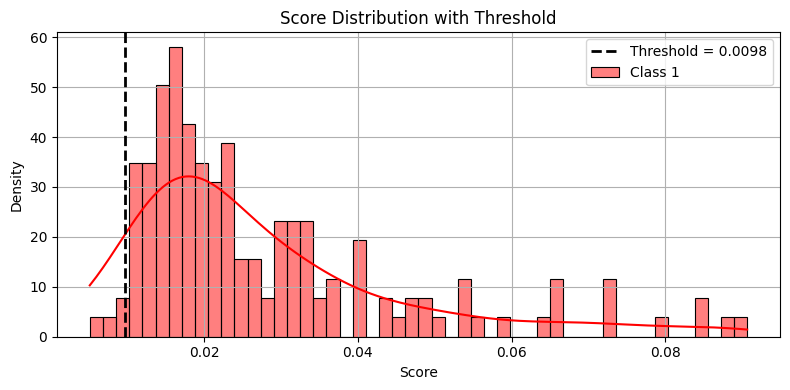

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution(y_true, scores_dict, threshold, title="Score Distribution with Threshold"):
    scores = np.array(scores_dict["mse"])
    y_true = np.array(y_true).astype(int)

    if scores.shape[0] != y_true.shape[0]:
        raise ValueError(f"Shape mismatch: scores ({scores.shape}) vs y_true ({y_true.shape})")

    # Split by class
    unique_classes = np.unique(y_true)
    plt.figure(figsize=(8, 4))

    if 0 in unique_classes:
        class_0_scores = scores[y_true == 0]
        sns.histplot(class_0_scores, bins=50, color='blue', label='Class 0', kde=True, stat='density')
    else:
        print("⚠️ No Class 0 samples in y_true")

    if 1 in unique_classes:
        class_1_scores = scores[y_true == 1]
        sns.histplot(class_1_scores, bins=50, color='red', label='Class 1', kde=True, stat='density')
    else:
        print("⚠️ No Class 1 samples in y_true")

    # Threshold line
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
    plt.title(title)
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


print(len(y_true), len(scores_dict["mse"]))  # Should be the same

plot_score_distribution(y_true, scores_dict, best_thresholds["mse"])


## NSCLC Analysis

In [45]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from skimage.transform import resize
import glob

class NoduleDatasetNSCLC(Dataset):
    def __init__(self, npy_dir):
        self.npy_dir = npy_dir
        self.nodule_files = sorted(
            glob.glob(os.path.join(npy_dir, "*_patch_1.npy"))
        )
        if not self.nodule_files:
            raise ValueError(f"No '_patch_1.npy' files found in: {npy_dir}")

    def __len__(self):
        return len(self.nodule_files)

    def __getitem__(self, idx):
        file_path = self.nodule_files[idx]
        npy_data = np.load(file_path)
        npy_data_resized = resize(npy_data, (32, 32), mode='wrap', anti_aliasing=False)
        np_min, np_max = npy_data_resized.min(), npy_data_resized.max()
        if np_max > np_min:
            npy_data_resized = (npy_data_resized - np_min) / (np_max - np_min)
        else:
            npy_data_resized = npy_data_resized - np_min
        npy_data_resized = np.expand_dims(npy_data_resized, axis=0)
        sample_tensor = torch.from_numpy(npy_data_resized).float()
        label_tensor = torch.tensor(1.0).float()
        return sample_tensor, label_tensor

# --- DataLoader Factory ---
def create_nsclc_dataloader(npy_dir, batch_size=16, shuffle=False):
    dataset = NoduleDatasetNSCLC(npy_dir)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [50]:
import os

root_dir = '/data/Datasets/Lungs/NSCLC_Radiogenomics/NSCLC-Anot'

valid_cases = [
    folder for folder in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, folder, 'chest_ct')) and
       os.listdir(os.path.join(root_dir, folder, 'chest_ct'))
]

print(f"Number of folders with non-empty 'chest_ct': {len(valid_cases)}")


Number of folders with non-empty 'chest_ct': 161


In [30]:
import os

root_dir = '/data/Datasets/Lungs/NSCLC_Radiogenomics/NSCLC-Anot'

non_empty_folders = [
    folder for folder in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, folder)) and os.listdir(os.path.join(root_dir, folder))
]

print(f"Number of non-empty folders: {len(non_empty_folders)}")


Number of non-empty folders: 176


## Patches Creation

In [1]:
import os
import pandas as pd
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from skimage.transform import resize

# === CONFIG ===
BASE_PATH = "/data/Datasets/Lungs/NSCLC_Radiogenomics/manifest-1622561851074"
PATCH_SIZE = 32           # Final patch size (output)
CONTEXT_RADIUS = 64       # Area around centroid to extract before resizing
SHOW_PATCH = False
SAVE_PATCH = True
OUTPUT_DIR = "/data/Datasets/Lungs/NSCLC_Radiogenomics/patches_npy"

# === LOAD CSVs ===
annotations = pd.read_csv("/data/Datasets/Lungs/NSCLC_Radiogenomics/NSCLC-Anot/dataset-annotations.csv")
metadata = pd.read_csv("/data/Datasets/Lungs/NSCLC_Radiogenomics/manifest-1622561851074/metadata.csv")

# === Clean column names ===
annotations.columns = annotations.columns.str.strip()
metadata.columns = metadata.columns.str.strip()

# === Build mapping: Series UID → File Location ===
metadata_dict = dict(zip(metadata['Series UID'].astype(str), metadata['File Location']))

# === Helper: extract bigger region → resize to PATCH_SIZE ===
def extract_rescaled_patch(img, center_i, center_j, context_size, output_size):
    half = context_size // 2
    h, w = img.shape

    top = center_i - half
    bottom = center_i + half
    left = center_j - half
    right = center_j + half

    pad_top = max(0, -top)
    pad_left = max(0, -left)
    pad_bottom = max(0, bottom - h)
    pad_right = max(0, right - w)

    top = max(0, top)
    left = max(0, left)
    bottom = min(h, bottom)
    right = min(w, right)

    patch = img[top:bottom, left:right]
    patch = np.pad(
        patch,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode='constant',
        constant_values=0
    )
    resized = resize(patch, (output_size, output_size), order=1, mode='reflect', anti_aliasing=True)
    return resized

# === Main processing loop ===
for idx, row in annotations.iterrows():
    case = row['Case']
    series_uid = str(row['Instance UID']).strip()
    z_slice = int(row['Z'])

    if z_slice == 1:
        print(f"⏭️ Skipping Case {case} due to Z == 1")
        continue

    x_px = int(round(row['X Value']))
    y_px = int(round(row['Y Value']))

    print(f"\n🔍 Processing Case: {case} | Series UID: {series_uid} | Z = {z_slice}")

    if series_uid not in metadata_dict:
        print(f"⚠️ Series UID {series_uid} not found in metadata.csv")
        continue

    file_location = metadata_dict[series_uid]
    print(f"📄 metadata_dict[{series_uid}] = {file_location}")

    rel_path = file_location.lstrip("/\\")
    dicom_folder = os.path.normpath(os.path.join(BASE_PATH, rel_path))

    if not os.path.isdir(dicom_folder):
        print(f"❌ DICOM folder not found:\n  {dicom_folder}")
        continue

    dcm_filename = f"1-{z_slice:03d}.dcm"  # ⬅️ Zero-padded to 3 digits
    target_file = os.path.join(dicom_folder, dcm_filename)

    if not os.path.isfile(target_file):
        print(f"❌ DICOM file not found:\n  {target_file}")
        print(f"📁 Available files:\n  {os.listdir(dicom_folder)}")
        continue

    try:
        dcm = pydicom.dcmread(target_file)
        img = dcm.pixel_array
    except Exception as e:
        print(f"⚠️ Could not read slice: {target_file} → {e}")
        continue

    i, j = y_px, x_px
    patch = extract_rescaled_patch(img, i, j, CONTEXT_RADIUS, PATCH_SIZE)

    if SHOW_PATCH:
        plt.imshow(patch, cmap='gray')
        plt.title(f"Case {case} - Patch at ({i},{j})")
        plt.colorbar()
        plt.show()

    if SAVE_PATCH:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        patch_file = os.path.join(OUTPUT_DIR, f"{case}_patch.npy")
        np.save(patch_file, patch)



🔍 Processing Case: AMC-003 | Series UID: 1.3.6.1.4.1.14519.5.2.1.4334.1501.275306957428099088735043587644 | Z = 123
📄 metadata_dict[1.3.6.1.4.1.14519.5.2.1.4334.1501.275306957428099088735043587644] = ./NSCLC Radiogenomics/AMC-003/02-22-1995-NA-ThoraxLOWDOSECHESTCTNONCON Adult-00343/3.000000-THORAX LUNG 1MM-87644

🔍 Processing Case: AMC-005 | Series UID: 1.3.6.1.4.1.14519.5.2.1.4334.1501.162938158768722859985597214287 | Z = 131
📄 metadata_dict[1.3.6.1.4.1.14519.5.2.1.4334.1501.162938158768722859985597214287] = ./NSCLC Radiogenomics/AMC-005/07-21-1994-NA-ThoraxCHESTNONCONTRAST Adult-39484/3.000000-Chest  1.0  B45f-14287

🔍 Processing Case: AMC-006 | Series UID: 1.3.6.1.4.1.14519.5.2.1.4334.1501.127565890510066907452937805882 | Z = 124
📄 metadata_dict[1.3.6.1.4.1.14519.5.2.1.4334.1501.127565890510066907452937805882] = ./NSCLC Radiogenomics/AMC-006/08-09-1991-NA-CT CHEST ABD PELVIS WITH CON-72274/5.000000-LUNG 1 MM-05882

🔍 Processing Case: AMC-007 | Series UID: 1.3.6.1.4.1.14519.5.2.1.43

# Trash

In [10]:
import os

print(len(os.listdir("/home/arumota_pupils/Josue/EMBC_Extention/Data2/train/benign")))
print(len(os.listdir("/home/arumota_pupils/Josue/EMBC_Extention/Data/train/benign")))

312
312


FileNotFoundError: [Errno 2] No such file or directory: '/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed/train/benign'

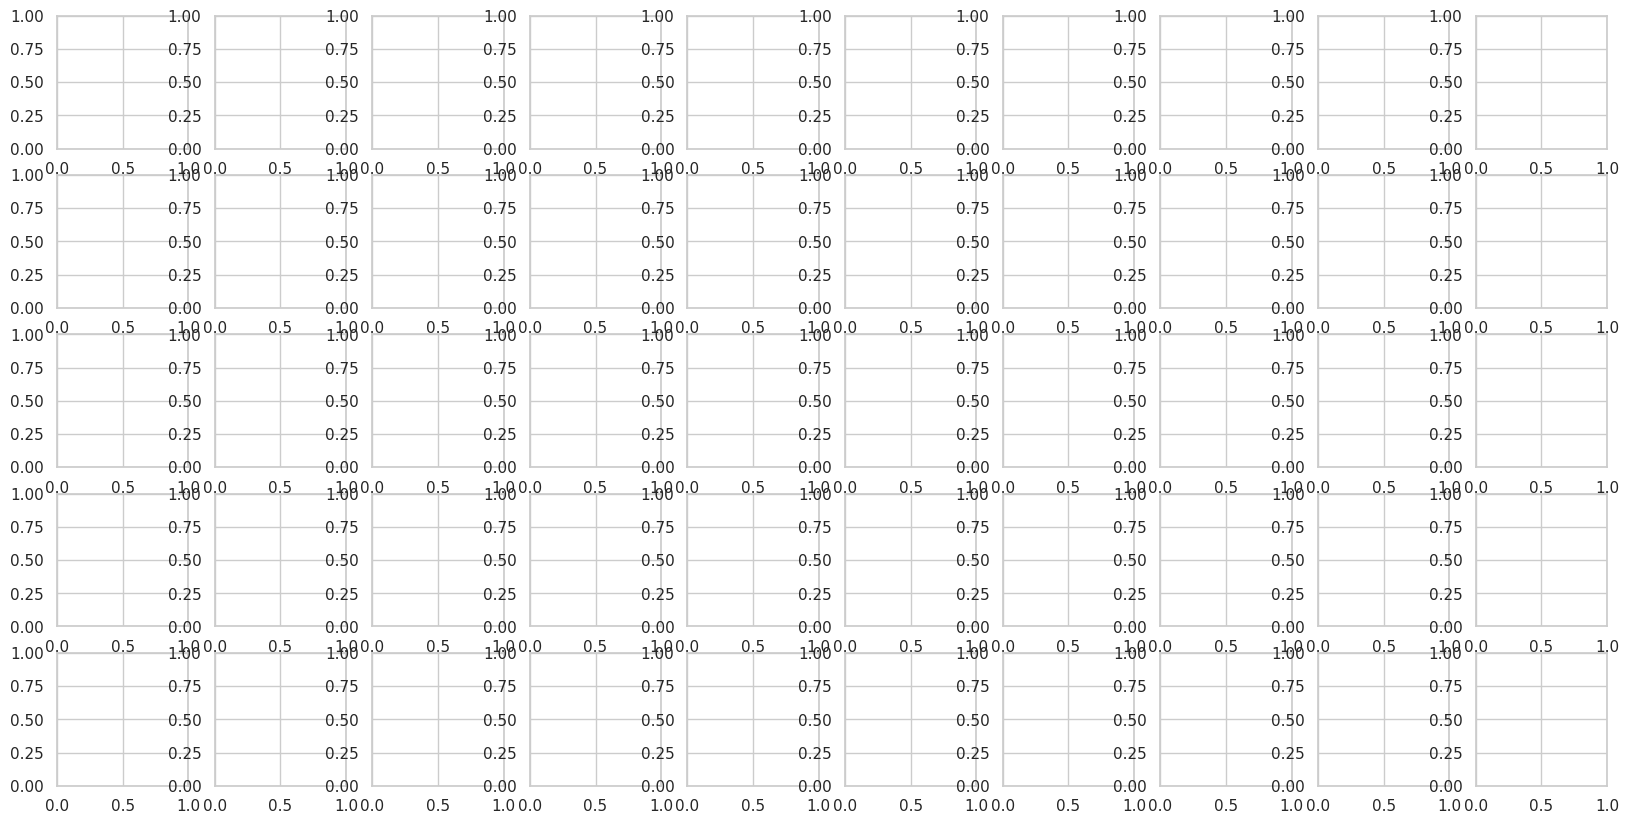

In [19]:
# Show an image from data 2 train benign and its properties
import matplotlib.pyplot as plt
import numpy as np

# Load the image

# now print a plot with the first 10 images from the benign folder
import matplotlib.pyplot as plt
import numpy as np

# Load the image

fig, axs = plt.subplots(5, 10, figsize=(20, 10))
for i in range(50):
    img = np.load(os.path.join("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed/train/benign", sorted(os.listdir("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed/train/benign"))[i]))
    axs[i//10, i%10].imshow(img, cmap='gray')
    axs[i//10, i%10].axis('off')
plt.show()


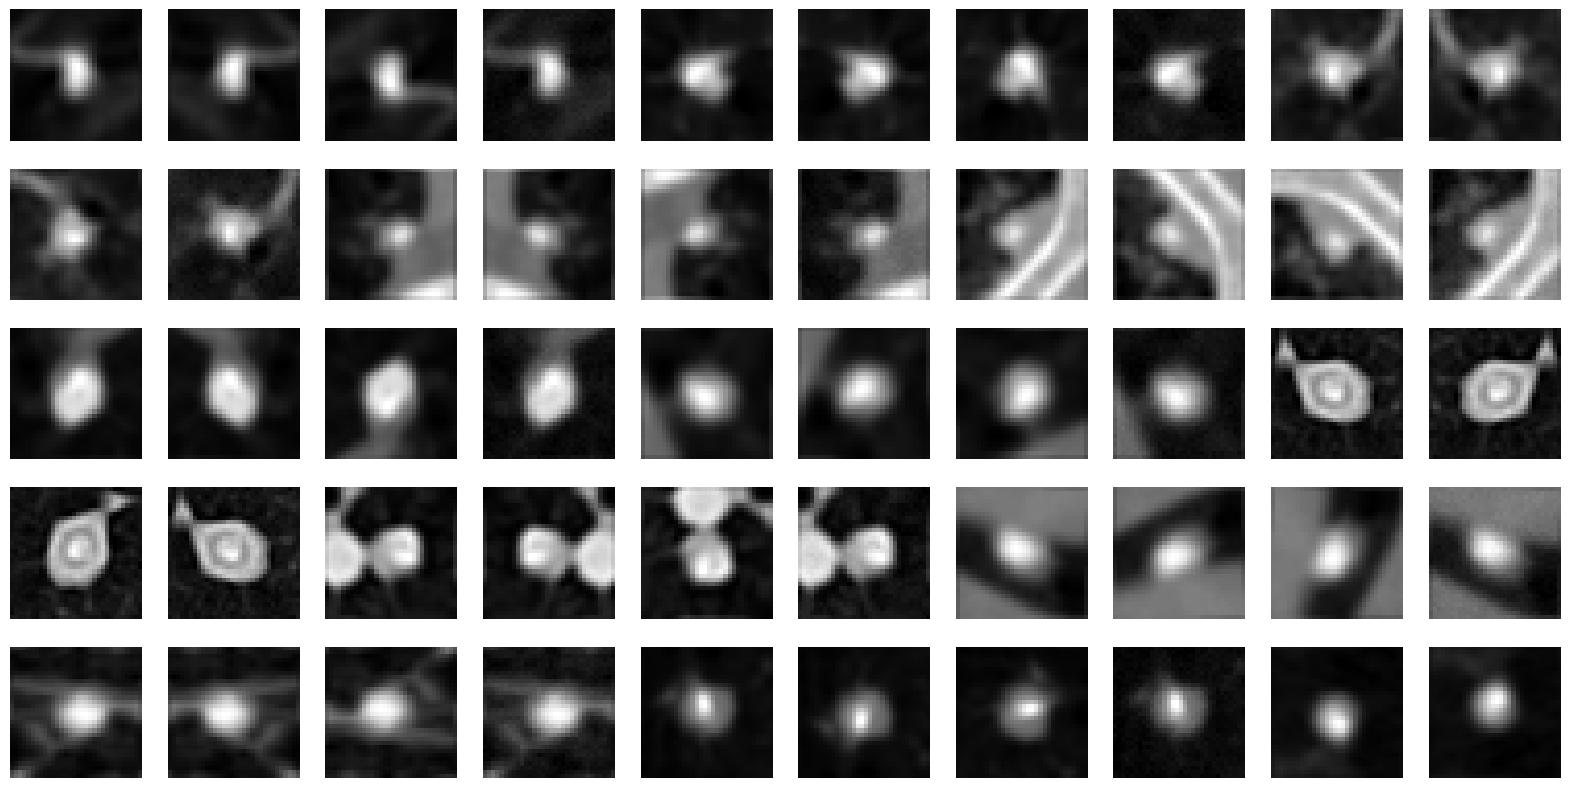

In [9]:
# Show an image from data 2 train benign and its properties
import matplotlib.pyplot as plt
import numpy as np
import os 

# Load the image

fig, axs = plt.subplots(5, 10, figsize=(20, 10))
for i in range(50):
    img = np.load(os.path.join("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_v2/train/benign", sorted(os.listdir("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_v2/train/benign"))[i]))
    axs[i//10, i%10].imshow(img, cmap='gray')
    axs[i//10, i%10].axis('off')
plt.show()

# Concordancias histopatológicas con radiológicas

In [12]:
df = pd.read_csv('/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/4_merged_radiologists.csv')

# Filtrar solo los registros donde 'hist_information' es 1
df_filtrado = df[df['hist_information'] == 1]

# Clasificar los nódulos según 'malignancy'
def clasificar_malignancy(x):
    if x < 3:
        return 'benigno'
    elif x > 3:
        return 'maligno'
    else:
        return 'indeterminado'

df_filtrado['malignancy_class'] = df_filtrado['malignancy'].apply(clasificar_malignancy)

# Clasificar los nódulos según 'nodule_value'
def clasificar_nodule_value(x):
    if x == 1:
        return 'benigno'
    elif x > 1:
        return 'maligno'
    else:
        return 'indeterminado'

df_filtrado['nodule_value_class'] = df_filtrado['nodule_value'].apply(clasificar_nodule_value)

# Crear la rejilla (matriz de confusión)
rejilla = pd.crosstab(df_filtrado['nodule_value_class'], df_filtrado['malignancy_class'])

# Mostrar la rejilla
print("Rejilla de clasificación (Matriz de confusión):")
print(rejilla)

/tmp/ipykernel_748002/684341129.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['malignancy_class'] = df_filtrado['malignancy'].apply(clasificar_malignancy)
/tmp/ipykernel_748002/684341129.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['nodule_value_class'] = df_filtrado['nodule_value'].apply(clasificar_nodule_value)


Rejilla de clasificación (Matriz de confusión):
malignancy_class    benigno  indeterminado  maligno
nodule_value_class                                 
benigno                   3              7        4
indeterminado             5              4        5
maligno                   4             17       19


## Cantidad nódulos histopatológicos

In [3]:
import pandas as pd
df = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/transformed_hist.csv")

# Filtrar los nódulos donde method != 0
filtered_df = df[df['method'] != 0]

# Clasificar los nódulos
filtered_df['class'] = filtered_df['malignancy'].apply(lambda x: 'benigno' if x == 1 else ('maligno' if x > 1 else 'indeterminado'))

# Contar cuántos nódulos hay de cada clase
counts = filtered_df['class'].value_counts()

counts

/tmp/ipykernel_808676/54349762.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['class'] = filtered_df['malignancy'].apply(lambda x: 'benigno' if x == 1 else ('maligno' if x > 1 else 'indeterminado'))


class
maligno    70
benigno    41
Name: count, dtype: int64

# ¿Hay nódulos indeterminados en mi dataset?

In [1]:
main_folder = "/data/Datasets/Lungs/processed_josue/"
csv = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_josue/4_radiologists.csv"

In [4]:
import os
import numpy as np
import pandas as pd

# Define the paths
main_folder = "/data/Datasets/Lungs/processed_josue/"
csv_path = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_josue/4_radiologists.csv"

# Load the CSV file
csv_data = pd.read_csv(csv_path)

# Function to extract malignancy for each .npy file
def process_npy_files(main_folder, csv_data):
    total_counts = {}

    for split in ['train', 'test']:
        split_counts = {}
        for label in ['benign', 'malignant']:
            folder_path = os.path.join(main_folder, split, label)
            
            # Ensure the folder exists
            if not os.path.exists(folder_path):
                print(f"Folder not found: {folder_path}")
                continue

            # Process each .npy file in the folder
            folder_counts = {}
            for npy_file in os.listdir(folder_path):
                if npy_file.endswith(".npy") and "_aug_" not in npy_file:
                    # Extract patient_id and nodule_number
                    file_parts = npy_file.replace(".npy", "").split("_")
                    if len(file_parts) < 2:
                        print(f"Unexpected file format: {npy_file}")
                        continue

                    patient_id = file_parts[0]
                    nodule_number = int(file_parts[1])

                    # Search for the malignancy value in the CSV
                    row = csv_data[(csv_data['patient_id'] == patient_id) & (csv_data['nodule_number'] == nodule_number)]

                    if not row.empty:
                        malignancy = row.iloc[0]['malignancy']
                        folder_counts[malignancy] = folder_counts.get(malignancy, 0) + 1
                    else:
                        print(f"Malignancy data not found for file: {npy_file}")

            # Print counts for the current folder
            print(f"Counts for {split}/{label}: {folder_counts}")

            # Add to split-level counts
            for malignancy, count in folder_counts.items():
                split_counts[malignancy] = split_counts.get(malignancy, 0) + count

        # Print counts for the current split
        print(f"Counts for {split}: {split_counts}")

        # Add to total counts
        for malignancy, count in split_counts.items():
            total_counts[malignancy] = total_counts.get(malignancy, 0) + count

    # Print total counts
    print(f"Total counts: {total_counts}")

# Execute the function
process_npy_files(main_folder, csv_data)


Counts for train/benign: {2: 23, 1: 50}
Counts for train/malignant: {4: 103, 5: 66}
Counts for train: {2: 23, 1: 50, 4: 103, 5: 66}
Counts for test/benign: {1: 53, 2: 21}
Counts for test/malignant: {4: 95, 5: 76, 3: 1}
Counts for test: {1: 53, 2: 21, 4: 95, 5: 76, 3: 1}
Total counts: {2: 44, 1: 103, 4: 198, 5: 142, 3: 1}


In [5]:
import os
import pandas as pd

# Define the paths
main_folder = "/data/Datasets/Lungs/processed_josue/"
csv_path = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_josue/4_radiologists.csv"

# Load the CSV file
csv_data = pd.read_csv(csv_path)

# Function to check for nodules with malignancy == 3
def check_malignancy_three(main_folder, csv_data):
    nodules_with_malignancy_3 = []
    for split in ['train', 'test']:
        for label in ['benign', 'malignant']:
            folder_path = os.path.join(main_folder, split, label)
            
            # Ensure the folder exists
            if not os.path.exists(folder_path):
                print(f"Folder not found: {folder_path}")
                continue

            # Process each .npy file in the folder
            for npy_file in os.listdir(folder_path):
                if npy_file.endswith(".npy") and "_aug_" not in npy_file:
                    # Extract patient_id and nodule_number
                    file_parts = npy_file.replace(".npy", "").split("_")
                    if len(file_parts) < 2:
                        print(f"Unexpected file format: {npy_file}")
                        continue

                    patient_id = file_parts[0]
                    nodule_number = int(file_parts[1])

                    # Search for the malignancy value in the CSV
                    row = csv_data[(csv_data['patient_id'] == patient_id) & (csv_data['nodule_number'] == nodule_number)]

                    if not row.empty:
                        malignancy = row.iloc[0]['malignancy']
                        if malignancy == 3:
                            nodules_with_malignancy_3.append({
                                "file": npy_file,
                                "split": split,
                                "label": label,
                                "patient_id": patient_id,
                                "nodule_number": nodule_number
                            })

    # Print results
    if nodules_with_malignancy_3:
        print("Nodules with malignancy == 3:")
        for nodule in nodules_with_malignancy_3:
            print(nodule)
    else:
        print("No nodules with malignancy == 3 found.")

# Execute the function
check_malignancy_three(main_folder, csv_data)


Nodules with malignancy == 3:
{'file': 'LIDC-IDRI-0484_1.npy', 'split': 'test', 'label': 'malignant', 'patient_id': 'LIDC-IDRI-0484', 'nodule_number': 1}


In [26]:
import pandas as pd

# Load the CSV file
csv_path = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/1_radiologists.csv"
df = pd.read_csv(csv_path)

# Find and display duplicate rows based on 'patient_id' and 'nodule_number'
duplicates = df[df.duplicated(subset=["patient_id", "nodule_number"], keep=False)]

if not duplicates.empty:
    print("Duplicates found:")
    print(duplicates[["patient_id", "nodule_number", "malignancy"]])
    print(len(duplicates))
else:
    print("No duplicates found.")

Duplicates found:
          patient_id  nodule_number  malignancy
12    LIDC-IDRI-0132              1           1
13    LIDC-IDRI-0132              2           1
14    LIDC-IDRI-0132              3           3
15    LIDC-IDRI-0132              4           5
16    LIDC-IDRI-0132              5           4
17    LIDC-IDRI-0132              6           3
29    LIDC-IDRI-0151              1           4
405   LIDC-IDRI-0132              1           4
406   LIDC-IDRI-0132              2           3
407   LIDC-IDRI-0132              3           3
408   LIDC-IDRI-0132              4           5
409   LIDC-IDRI-0132              5           4
410   LIDC-IDRI-0132              6           3
469   LIDC-IDRI-0151              1           3
816   LIDC-IDRI-0315              1           2
817   LIDC-IDRI-0315              2           3
818   LIDC-IDRI-0315              3           3
819   LIDC-IDRI-0315              4           5
820   LIDC-IDRI-0315              5           2
823   LIDC-IDRI-0315  